In [3]:
using Microgrids
using JuMP
using Printf
using HiGHS
using PyPlot
using PyCall
using CSV, DataFrames,MeshGrid
np=pyimport("numpy")

PyObject <module 'numpy' from 'C:\\Users\\FR00CSS0000000077985\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\numpy\\__init__.py'>

In [4]:
include("../../Microgrids.jl/examples/data/Microgrid_Wind-Solar-H2_data.jl");
include("../../Microgrids.jl/graphics.jl");

LoadError: SystemError: opening file "c:\\Users\\FR00CSS0000000077985\\Documents\\Centrale_Supelec\\Microgrids.jl\\examples\\data\\Microgrid_Wind-Solar-H2_data.jl": No such file or directory

In [ ]:
mg=new_microgrid()

Microgrid{Float64}(Project(25, 0.05, 1.0, "€"), [1453.0, 1331.0, 1214.0, 1146.0, 1078.0, 1035.0, 1032.0, 1072.0, 1142.0, 1208.0  …  1479.0, 1508.0, 1410.0, 1370.0, 1467.0, 1587.0, 1561.0, 1472.0, 1533.0, 1483.0], DispatchableCompound{Float64}(ProductionUnit{Float64}[ProductionUnit{Float64}(0.0, 0.0, 0.24, 1.0, 400.0, 0.02, 0.0, 25.0, 20000.0, 5000.0, 0.1, 1.0, 1.0, "L", "KWh")], ProductionUnit{Float64}[ProductionUnit{Float64}(2000.0, 0.0, 0.0625, 0.0, 1600.0, 0.0, 45.0, 15.0, 45000.0, 5000.0, 0.05, 1.0, 1.0, "Kg", "KWh")]), ProductionUnit{Float64}[ProductionUnit{Float64}(1800.0, 0.0, 56.0, 0.0, 1600.0, 0.0, 44.0, 20.0, 45000.0, 5000.0, 0.05, 1.0, 1.0, "KWh", "Kg")], ProductionUnit{Float64}(0.0, 0.0, 0.344, 0.0, 1600.0, 0.0, 17.0, 25.0, 45000.0, 5000.0, 0.3, 1.0, 1.0, "Kwh", "Kg"), TankCompound{Float64}(Tank{Float64}(0.0, 0.0, 0.0, 25.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0), Tank{Float64}(12000.0, 500.0, 4.0, 25.0, 0.0, 0.0, 0.0, 1.0, 14.0, 1.0, 1.0)), Battery{Float64}(5000.0, 350.0, 10.0

In [ ]:
Pload_max = maximum(Pload) # kW
    @printf("Max load power: %.1f kW", Pload_max)
    fc_size_max = 1.2 * Pload_max
    el_size_max = 4.0 * Pload_max
    batt_size_max = 7.0 * Pload_max
    pv_size_max = 7.0 * Pload_max
    gen_size_max = 0.0
    wind_size_max = 1800.0;
    hytank_size_max = 12 * Pload_max

Max load power: 1707.0 kW

20484.0

### functions definitions

In [ ]:
rval = (x -> round(x;digits=2)) ∘ value;

In [ ]:
function cost_check(model,lcoe)
     K=length(value.(model[:Pnl]))
    sizing=Sizing(value(model[:Cgen]),value(model[:Cbatt]), value(model[:Cpv]), value(model[:Cwind]),value(model[:Cfc]),value(model[:Cel]),value(model[:Ctank]),0.0,0.0)
   traj=OperationTraj(value.(model[:Pnl]),value.(model[:Pshed]),value.(model[:renew_potential]),zeros(Float64,K),value.(model[:Pfc]),
    value.(model[:Pel]),zeros(Float64,K),value.(model[:Ebatt]),value.(model[:Pbatt_dis]) .- value.(model[:Pbatt_cha]),value.(model[:LoH]),zeros(Float64,K),
    value.(model[:Pspill]),zeros(Float64,K))
ini=[0.0,value.(model[:LoH])[1]/sizing.Htank,value.(model[:Ebatt])[1]/sizing.Cbatt]
mg=new_microgrid(sizing,capex_def,ini,value.(model[:Pnl]) .+ value.(model[:renew_potential]))
    oper_stats = aggregation(mg,traj)
        # Eval the microgrid costs
    mg_costs = economics(mg, oper_stats)

    pv = mg.nondispatchables[1]
    wind = mg.nondispatchables[2]
    elyz=mg.electrolyzer[1]
    fc= mg.dispatchables.fuel_cell[1]
    hytank= mg.tanks.h2Tank
    bt=mg.storage
   



Telyz = min((1-Eol) /( oper_stats.elyz_hours*deg_ratio_rt+ oper_stats.elyz_starts*deg_ratio_st), elyz.lifetime_calendar)
Tfc = min((1-Eol) /( oper_stats.fc_hours*deg_ratio_rt+ oper_stats.fc_starts*deg_ratio_st),fc.lifetime_calendar)
        
Tbt = min(bt.lifetime_cycles/oper_stats.storage_cycles,bt.lifetime_calendar) 
    elyz_size_ann_bb= value(model[:Cel])*CRF(mg.project.discount_rate,Telyz)
     fc_size_ann_bb= value(model[:Cfc])*CRF(mg.project.discount_rate,Tfc)
     batt_size_ann_bb= value(model[:Cbatt])*CRF(mg.project.discount_rate,Tbt) 
    @printf( "X* batt: %.1f kWh , PV: %.1f kW , Wind : %.1f kW , elyz : %1.f kW fc : %.1f kW,  h2_tank : %1.f kg \n",sizing.Cbatt, sizing.Cpv,sizing.Cwind,sizing.Cel, sizing.Cfc,sizing.Htank)
@printf( "LCOE MILP: %.6f \$/kWh , real LCOE: %.6f \$/kWh , error : %.2f%% \n",lcoe, mg_costs.lcoe,100*(lcoe-mg_costs.lcoe)/mg_costs.lcoe)


       println( "elyz: ", rval(model[:Pel_rated_ann]), " kW/an, ","elyz_bb: ", rval(elyz_size_ann_bb), " kW/an, ",
        "fc: ", rval(model[:Pfc_rated_ann]), " kW/an, ","fc_bb: ", rval(fc_size_ann_bb), " kW/an, ",
        "batt: ", rval(model[:Esto_rated_ann]), " kWh/an, ",  "batt_bb: ", rval(batt_size_ann_bb), " kWh/an ")

    
       println("battery costs LP; om :",bt.om_price*sizing.Cbatt,  "   invest + replace   " ,rval(model[:Esto_rated_ann])*bt.investment_price, "\n",
     "   BB ; om : " ,mg_costs.storage.om*CRF(mg.project.discount_rate,mg.project.lifetime),  "  invest + replace   ", (mg_costs.storage.investment + mg_costs.storage.replacement)*CRF(mg.project.discount_rate,mg.project.lifetime),"  invest + replace - salvage :", (mg_costs.storage.investment + mg_costs.storage.replacement + mg_costs.storage.salvage )*CRF(mg.project.discount_rate,mg.project.lifetime))
    
    println("\n electrolyzer costs LP; om :",elyz.om_price*sizing.Cel,  "   invest + replace   " ,rval(model[:Pel_rated_ann])*elyz.investment_price, "\n",
     "            BB ; om : " ,mg_costs.electrolyzer.om*CRF(mg.project.discount_rate,mg.project.lifetime),  "  invest + replace   ", (mg_costs.electrolyzer.investment + mg_costs.electrolyzer.replacement)*CRF(mg.project.discount_rate,mg.project.lifetime),"  invest + replace - salvage :", (mg_costs.electrolyzer.investment + mg_costs.electrolyzer.replacement + mg_costs.electrolyzer.salvage )*CRF(mg.project.discount_rate,mg.project.lifetime))
               
     println("\n fuel_cell costs LP; om :",fc.om_price*sizing.Cfc,  "   invest + replace   " ,rval(model[:Pfc_rated_ann])*fc.investment_price, "\n",
     "            BB ; om : " ,mg_costs.fuel_cell.om*CRF(mg.project.discount_rate,mg.project.lifetime),  "  invest + replace   ", (mg_costs.fuel_cell.investment + mg_costs.fuel_cell.replacement)*CRF(mg.project.discount_rate,mg.project.lifetime),"  invest + replace - salvage :", (mg_costs.fuel_cell.investment + mg_costs.fuel_cell.replacement + mg_costs.fuel_cell.salvage )*CRF(mg.project.discount_rate,mg.project.lifetime))
             
     
   # println("batt: ", rval(model[:Esto_rated_ann]), " kWh/an, ",  "batt_bb: ", rval(batt_size_ann_bb), " kWh/an ")
  #   println("gen: ", rval(value(model[:Pgen_rated_ann])), " kW/an, ",  "gen_bb: ", rval(gen_size_ann_bb), " kWh/an ")
  
  #  println("battery costs LP; om :",bt.om_price*sizing.Cbatt,  "   invest + replace   " ,rval(model[:Esto_rated_ann])*bt.investment_price, "\n",
 #    "   BB ; om : " ,mg_costs.storage.om*CRF(mg.project.discount_rate,mg.project.lifetime),  "  invest + replace   ", (mg_costs.storage.investment + mg_costs.storage.replacement)*CRF(mg.project.discount_rate,mg.project.lifetime),"  invest + replace - salvage :", (mg_costs.storage.investment + mg_costs.storage.replacement + mg_costs.storage.salvage )*CRF(mg.project.discount_rate,mg.project.lifetime))
    
   
    return mg,traj,oper_stats,mg_costs
    
end

cost_check (generic function with 1 method)

In [ ]:
function cost_check1(model,lcoe)
    K=length(value.(model[:Pnl]))
    sizing=Sizing(value(model[:Cgen]),value(model[:Cbatt]), value(model[:Cpv]), value(model[:Cwind]),  value(model[:Cel]), value(model[:Cfc]), value(model[:Ctank]),0.0,0.0)
    traj=OperationTraj(value.(model[:Pnl]),value.(model[:Pshed]),value.(model[:renew_potential]),zeros(Float64,K),value.(model[:Pfc]),
    value.(model[:Pel]),zeros(Float64,K),value.(model[:Ebatt]),value.(model[:Pbatt_dis]) .- value.(model[:Pbatt_cha]),value.(model[:LoH]),zeros(Float64,K),
    value.(model[:Pspill]),zeros(Float64,K))
ini=[0.0,value.(model[:LoH])[1]/sizing.Htank,value.(model[:Ebatt])[1]/sizing.Cbatt]
mg=new_microgrid(sizing,capex_def,ini,value.(model[:Pnl]) .+ value.(model[:renew_potential]))
    oper_stats = aggregation(mg,traj)
        # Eval the microgrid costs
    mg_costs = economics(mg, oper_stats)

    pv = mg.nondispatchables[1]
    wind = mg.nondispatchables[2]
    elyz=mg.electrolyzer[1]
    fc= mg.dispatchables.fuel_cell[1]
    hytank= mg.tanks.h2Tank
    bt=mg.storage

Telyz = min((1-Eol) /( oper_stats.elyz_hours*deg_ratio_rt+ oper_stats.elyz_starts*deg_ratio_st), elyz.lifetime_calendar)
Tfc = min((1-Eol) /( oper_stats.fc_hours*deg_ratio_rt+ oper_stats.fc_starts*deg_ratio_st),fc.lifetime_calendar)
  #  Tfc = fc.lifetime_hours / oper_stats.fc_hours
        
Tbt = min(bt.lifetime_cycles/oper_stats.storage_cycles,bt.lifetime_calendar) 
    elyz_size_ann_bb= value(model[:Cel])*CRF(mg.project.discount_rate,Telyz)
     fc_size_ann_bb= value(model[:Cfc])*CRF(mg.project.discount_rate,Tfc)
     batt_size_ann_bb= value(model[:Cbatt])*CRF(mg.project.discount_rate,Tbt) 
    @printf( "X* batt: %.1f kWh , PV: %.1f kW , Wind : %.1f kW , elyz : %1.f kW fc : %.1f kW,  h2_tank : %1.f kg \n",sizing.Cbatt, sizing.Cpv,sizing.Cwind,sizing.Cel, sizing.Cfc,sizing.Htank)
@printf( "LCOE MILP: %.6f \$/kWh , real LCOE: %.6f \$/kWh , error : %.2f%% \n",lcoe, mg_costs.lcoe,100*(lcoe-mg_costs.lcoe)/mg_costs.lcoe)
     
    println( "elyz: ", rval(model[:Pel_rated_ann]), " kW/an, ","elyz_bb: ", rval(elyz_size_ann_bb), " kW/an, ",
        "fc: ", rval(model[:Pfc_rated_ann]), " kW/an, ","fc_bb: ", rval(fc_size_ann_bb), " kW/an, ",
        "batt: ", rval(model[:Esto_rated_ann]), " kWh/an, ",  "batt_bb: ", rval(batt_size_ann_bb), " kWh/an ")
    
    println("battery costs LP; om :",bt.om_price*sizing.Cbatt,  "   invest + replace   " ,rval(model[:Esto_rated_ann])*bt.investment_price, "\n",
     "   BB ; om : " ,mg_costs.storage.om*CRF(mg.project.discount_rate,mg.project.lifetime),  "  invest + replace   ", (mg_costs.storage.investment + mg_costs.storage.replacement)*CRF(mg.project.discount_rate,mg.project.lifetime),"  invest + replace - salvage :", (mg_costs.storage.investment + mg_costs.storage.replacement + mg_costs.storage.salvage )*CRF(mg.project.discount_rate,mg.project.lifetime))
    
    println("\n electrolyzer costs LP; om :",elyz.om_price*sizing.Cel,  "   invest + replace   " ,rval(model[:Pel_rated_ann])*elyz.investment_price, "\n",
     "            BB ; om : " ,mg_costs.electrolyzer.om*CRF(mg.project.discount_rate,mg.project.lifetime),  "  invest + replace   ", (mg_costs.electrolyzer.investment + mg_costs.electrolyzer.replacement)*CRF(mg.project.discount_rate,mg.project.lifetime),"  invest + replace - salvage :", (mg_costs.electrolyzer.investment + mg_costs.electrolyzer.replacement + mg_costs.electrolyzer.salvage )*CRF(mg.project.discount_rate,mg.project.lifetime))
               
     println("\n fuel_cell costs LP; om :",fc.om_price*sizing.Cfc,  "   invest + replace   " ,rval(model[:Pfc_rated_ann])*fc.investment_price, "\n",
     "            BB ; om : " ,mg_costs.fuel_cell.om*CRF(mg.project.discount_rate,mg.project.lifetime),  "  invest + replace   ", (mg_costs.fuel_cell.investment + mg_costs.fuel_cell.replacement)*CRF(mg.project.discount_rate,mg.project.lifetime),"  invest + replace - salvage :", (mg_costs.fuel_cell.investment + mg_costs.fuel_cell.replacement + mg_costs.fuel_cell.salvage )*CRF(mg.project.discount_rate,mg.project.lifetime))
               
    return mg,traj,oper_stats,mg_costs
    
end

cost_check1 (generic function with 1 method)

In [ ]:
function CRF(i,T)
    if i != 0.0
        a = (1+i)^T
        return i*a/(a-1)
    else
        return 1/T
    end
end
CRF(0.05, 25)
CRFproj(T) = CRF(mg.project.discount_rate, T) 

CRFproj (generic function with 1 method)

In [ ]:
"""reduce the year time series `x` to `ndays` ≤ 365
sr=24: data sampling rate / day. 24 means hourly time step.

The method is *basic*:
it samples `ndays` days evenly spaced by (365 ÷ `ndays`) days

with ndays=365, returns the orinal series
"""
function ts_reduction(x, ndays, sr=24)
    out = zeros(ndays*sr)
    @assert ndays<=365
    Δdays = 365 ÷ ndays
    for i in 1:ndays
        offset_in = (i-1)*Δdays*sr
        offset_out = (i-1)*sr
        out[offset_out+1:offset_out+sr] = x[offset_in+1:offset_in+sr]
    end
    return out
end

ts_reduction

In [ ]:

"""intercept and slope of tangent to function g:z → 1/(1-e^(-1/z))  at point `z0`

Usage: with gi, g1 = g_asym(z0),
then g(z) ~ gi + g1*z around z0
gi: intercept at z=0
g1: slope
"""
function g_tan(z0)
    z=z0
    emiz = exp(-1/z)
    g = 1/(1-emiz) # g(z)
    g1 = emiz/(z^2*(1-emiz)^2) # g'(z)
    ginter = g - g1*z
    return ginter, g1
end
g_tan(1e-3), g_tan(1/2), g_tan(1e3)
     

((1.0, 0.0), (0.7944868122665105, 0.7240616609663105), (0.500166666631003, 0.9999999166667313))

In [ ]:

"""Piecewise linear approximation of “annualized size” function of size and usage

Parameters:
- Xann, X, U: JuMP variables or expressions
- discount_rate: Real number in [0,1] (negative discount not implemented)
- z_tan: list z values where to use tangents of g(z).

Recommended values:
- z_tan = [0.5]: 5% CRF underestimation error
- z_tan = [0.28, 0.5, 1.0]: 1.6% error
- z_tan = [0.20, 0.28, 0.37, 0.50, 0.68, 1.0, 1.7, 4.0]: 0.23% error

Tangents at z=0 and z->infty are also added, so no need to add these.
"""
function cons_Xann_usage!(model, Xann, X, U, discount_rate, z_tan=[0.28, 0.5, 1.0])
    r = discount_rate/log(1+discount_rate)
    @constraint(model, Xann >= X*discount_rate)
    @constraint(model, Xann >= X*discount_rate*0.5 + U*r)
    tan_params = [ # ginter, g1 for each z0 in z_tan, including z=0 and +infty
        (1.0, 0.); 
        [(g_tan(z0)[1], g_tan(z0)[2]) for z0 in z_tan];
        (0.5, 1.0)
    ]
    ntan = length(tan_params)
    cvec = @constraint(model, [k=1:ntan],
        Xann >= X*discount_rate*tan_params[k][1]
              + U*r*tan_params[k][2]
    )
    cname = "c_" * name(Xann) *"_"* name(X) *"_"* name(U)
    set_name.(cvec, [cname * "[$k]" for k=1:ntan])
    return cvec
end

cons_Xann_usage!

In [ ]:

"""Piecewise linear approximation of “annualized size” function of size and usage

Parameters:
- Xann, X, U: JuMP variables or expressions
- discount_rate: Real number in [0,1] (negative discount not implemented)
- z_tan: list z values where to use tangents of g(z).

Recommended values:
- z_tan = [0.5]: 5% CRF underestimation error
- z_tan = [0.28, 0.5, 1.0]: 1.6% error
- z_tan = [0.20, 0.28, 0.37, 0.50, 0.68, 1.0, 1.7, 4.0]: 0.23% error

Tangents at z=0 and z->infty are also added, so no need to add these.
"""
function cons_( X, U, discount_rate,lf, z_tan=[0.28, 0.5, 1.0])
    r = discount_rate/log(1+discount_rate)
  
    tan_params = [ # ginter, g1 for each z0 in z_tan, including z=0 and +infty
        (1.0, 0.); 
        [(g_tan(z0)[1], g_tan(z0)[2]) for z0 in z_tan];
        (0.5, 1.0)
    ]
    ntan = length(tan_params)
    cvec =  collect(X*discount_rate*tan_params[k][1] + U*r*tan_params[k][2] for k=1:ntan)
       
    
    xann=max(X*discount_rate,X*CRF(discount_rate,lf),X*discount_rate*0.5 + U*r,cvec...)
   
end

cons_

### MILP Formulation modifié
Milp formulation for the sizing and ooperation optimization of a microgrid with PV, Wind, Batteries and a Diesel generator. Only the generator and the battery will be optimized. Renewables sources are fixed.

In [ ]:
"""Setup microgrid sizing optimization model using JuMP

Parameters:
- `shed_max`: load shedding penalty threshold should be in  [0,1[
- `ndays=365`: data reduction
-  some price params (keyword params)
-  some tolerances params (keyword params)

Sizing maximum bounds are taken as the global variables
fc_size_max,
elyz_size_sto_max,
hytank_size_max,
wind_size_max,
pv_size_max,
batt_size_max

Returns:
- mg: base microgrid
- JuMP model
- LCOE expression
"""
function setup_optim_mg_jump2(mg,shed_max,optimizer;
    ndays=365,fixed_lifetimes=false,rel_mip_gap = -1 ,abs_mip_gap = -1 ,time_up=64800,min_rt=1,mipfocus=-1,file_name="")
 
co=365/ndays # correction factor to get annual values
dt = mg.project.timestep
discount_rate=mg.project.discount_rate
 K = ndays*24 # h
ts_reduction_ndays(x) = ts_reduction(x, ndays)

Pload = mg.load |> ts_reduction_ndays;
Eload_desired = sum(Pload)*dt*365/ndays


cf_pv   = Ppv1k |> ts_reduction_ndays
cfwind = cf_wind |> ts_reduction_ndays;

pv = mg.nondispatchables[1]
wind = mg.nondispatchables[2]
gen= mg.dispatchables.generator[1]
bt=mg.storage
el=mg.electrolyzer[1]
fc= mg.dispatchables.fuel_cell[1]
hytank= mg.tanks.h2Tank    

   
### JuMP model ###
  model = Model(optimizer;add_bridges = false)
     set_attribute(model, "DisplayInterval", 100)
    set_attribute(model, "LogFile", file_name)
    set_attribute(model, "FeasibilityTol", 1e-9)
#set_silent(model)
set_string_names_on_creation(model, false)
#set_attribute(model, MOI.NumberOfThreads(), 1)
set_attribute(model, MOI.TimeLimitSec() , time_up) # optimization time limit
    #set_attribute(model, "presolve", 1)
# absolute tolerance MIP gap setting up
if mipfocus >=0
set_attribute(model, "MIPFocus" , mipfocus) 
end
if abs_mip_gap >=0
    set_attribute(model, MOI.AbsoluteGapTolerance() , abs_mip_gap) 
end

# relartive tolerance MIP gap setting up
if rel_mip_gap >=0
    set_attribute(model, MOI.RelativeGapTolerance() , rel_mip_gap) 
end
    @variables(model, begin
    0 <= Cbatt <=batt_size_max
    0 <= Cgen <=gen_size_max
    0 <= Cpv <= pv_size_max
    0 <= Cwind <=wind_size_max
    0 <= Cel<=el_size_max
    0 <= Cfc <=fc_size_max
    0 <= Ctank<=hytank_size_max
end) 

     # Non dispatchable sources (renewables)
@variable(model, pv_potential[1:K])
@constraint(model, pv_potential .== Cpv*cf_pv)
@variable(model, wind_potential[1:K])
@constraint(model, wind_potential .== Cwind*cfwind)

 @expression(model,renew_potential,pv_potential + wind_potential)
    
    # desired net load (before spillage of excess renewables and load shedding)
@variable(model, Pnl[1:K])
@constraint(model, Pnl .== Pload .- renew_potential);

    
    
#sizing variables ; battery and generatore capacities


### Components operation variables
    
## generator
@variable(model, Pgen[1:K] >= 0) ; # generator instantaneous power
      

@variable(model, δgen[1:K], Bin);  # generator statuts (on/off)
@variable(model, Δgen[1:K]>=0) # generator starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c1[k=2:K],Δgen[k]>=δgen[k]-δgen[k-1] # When the generator was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c2[k=1:K], Δgen[k]<=δgen[k]  # when the generator is off Δ(k)=0
    c3[k=2:K], δgen[k-1] + Δgen[k] <= 1 # When the generator was "on" at the previous instant, Δ(k)=0
            Δgen[1]==0
end);
## fuel cell
@variable(model, Pfc[1:K] >= 0) ; # generator instantaneous power
      

@variable(model, δfc[1:K], Bin);  # fuel cell statuts (on/off)
@variable(model, Δfc[1:K]>=0) # fuel cell starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c4[k=2:K],Δfc[k]>=δfc[k]-δfc[k-1] # When the fuel cell was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c5[k=1:K], Δfc[k]<=δfc[k]  # when the fuel cell is off Δ(k)=0
    c6[k=2:K], δfc[k-1] + Δfc[k] <= 1 # When thefuel cell was "on" at the previous instant, Δ(k)=0
            Δfc[1]==0
end);
## electrolyser
@variable(model, Pel[1:K] >= 0) ; # electrolyser instantaneous power
@variable(model, δel[1:K], Bin);  # electrolyser statuts (on/off)
@variable(model, Δel[1:K]>=0) # electrolyser starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c7[k=2:K],Δel[k]>=δel[k]-δel[k-1] # When the electrolyser was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c8[k=1:K], Δel[k]<=δel[k]  # when the electrolyser is off Δ(k)=0
    c9[k=2:K], δel[k-1] + Δel[k] <= 1 # When the electrolyser was "on" at the previous instant, Δ(k)=0
            Δel[1]==0
end);
     # Hydrogen compound

# Battery
@variable(model, δdis[1:K], Bin); 
@variable(model, δcha[1:K], Bin); 
@variables(model, begin 
Pbatt_cha[1:K] >=0 # battery instantaneous charge power
Pbatt_dis[1:K] >=0 # battery instantaneous discharge power
Ebatt[1:K+1]  # battery energy level
end) ;
    
# spillage and shedding power
@variables(model, begin 
Pspill[1:K] >= 0
Pshed[1:K] >= 0         
end) ;
    
### Battery operation constraints
@constraints(model, begin
Ebatt .<= Cbatt*bt.SoC_max # battery maximum energy
Ebatt .>= bt.SoC_min*Cbatt # tank minimum usable capacity
battery_dynamic[k=1:K] , Ebatt[k+1] == Ebatt[k] + (Pbatt_cha[k] - Pbatt_dis[k] - bt.loss_factor*(Pbatt_cha[k]+Pbatt_dis[k]))*dt # battery storage dynamic
Ebatt[1] == Ebatt[end] # periodicity constraint
δdis .+ δcha .<= 1
            
end);
    
@variable(model, Zdis[1:K]>=0)
@constraints(model, begin
Zdis.<= batt_size_max .* δdis
Zdis.>= Cbatt .- batt_size_max .* (1 .- δdis)
Zdis.<= Cbatt
Pbatt_lim_dis, Pbatt_dis .<= Zdis .* bt.discharge_rate # maximum charge limite
 Pbatt_dis .>= 1e-16 .* δdis 
end); 
    
    
@variable(model, Zcha[1:K]>=0)
@constraints(model, begin
Zcha.<= batt_size_max .* δcha
Zcha.>= Cbatt .- batt_size_max .* (1 .- δcha)
Zcha.<= Cbatt
Pbatt_lim_cha, Pbatt_cha .<= Zcha .* bt.charge_rate # maximum discharge limite
             Pbatt_cha  .>= 1e-16 .* δcha 
end);   
    
### Generator operation constraints
    
# Taking account Pgen minimal value 
@variable(model, Zgen[1:K]>=0)
@constraints(model, begin
Zgen.<= gen_size_max .* δgen
Zgen.>= Cgen .- gen_size_max .* (1 .- δgen)
Zgen.<= Cgen
end);      
@constraints(model, begin
 Pgen .<= Zgen 
 Pgen .>= Zgen*gen.minimum_load_ratio 
end);
# Taking account generator minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δgen[k]-δgen[k+i]<=0)
    end
end

### electrolyser operation constraints
    
# Taking account Pel minimal value 
@variable(model, Zel[1:K]>=0)
@constraints(model, begin
Zel.<= el_size_max .* δel
Zel.>= Cel .- el_size_max .* (1 .- δel)
Zel.<= Cel
end);      
@constraints(model, begin
 Pel .<= Zel 
 Pel .>= Zel*el.minimum_load_ratio
end);
# Taking account electrolyser minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δel[k]-δel[k+i]<=0)
    end
end

    
### fuel cell operation constraints
    
# Taking account Pfc minimal value 
@variable(model, Zfc[1:K]>=0)
@constraints(model, begin
Zfc.<= fc_size_max .* δfc
Zfc.>= Cfc .- fc_size_max .* (1 .- δfc)
Zfc.<= Cfc
end);      
@constraints(model, begin
 Pfc .<= Zfc 
 Pfc .>= Zfc*fc.minimum_load_ratio 
end);
# Taking account electrolyser minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δfc[k]-δfc[k+i]<=0)
    end
end
  
@constraints(model, begin 
    δfc .+ δel .<=1 
    Pspill .<= (pv_size_max .+ wind_size_max)*(1 .- δdis)
    Pspill .<= (pv_size_max .+ wind_size_max)*(1 .- δfc)
end)
   
    
@variable(model, 
    LoH[1:K+1]  >= 0 ) ;# hydrogen tank level

@constraints(model, begin
tank_lim_sup, LoH .<= hytank.max_filling_ratio * Ctank # tank maximum usable capacity 
tank_lim_inf, LoH .>= hytank.min_filling_ratio *  Ctank # tank minimum usable capacity
hytank_dynamic[k=1:K] , LoH[k+1] == LoH[k] - Pfc[k] * fc.consumption_slope*dt + (Pel[k]/el.consumption_slope)*dt # tank dynamic
LoH[1] == LoH[end] # periodicity constraint
end);
    
    
# shedding limit constraint
if shed_max == 0.0
    fix.(Pshed, 0.0; force=true);
else
    Eshed = @expression(model,sum(Pshed)*dt * 365/ndays)
    @constraint(model, Eshed <= Eload_desired*shed_max)
end
    
# Power balance constraint
@constraint(model,grid_balance, Pnl .== Pbatt_dis .- Pbatt_cha .+ Pfc .+ Pshed .- Pspill .- Pel .+ Pgen )

   @variable(model, Θgen[1:K]>=0)
    @constraints(model, begin
    Θgen.<= gen_size_max .* Δgen
    Θgen.>= Cgen .- gen_size_max .* (1 .- Δgen)
    Θgen.<= Cgen
    end);
        
    @variable(model, Θfc[1:K]>=0)
    @constraints(model, begin
    Θfc.<= fc_size_max .* Δfc
    Θfc.>= Cfc .- fc_size_max .* (1 .- Δfc)
    Θfc.<= Cfc
    end);
        
    @variable(model, Θel[1:K]>=0)
    @constraints(model, begin
    Θel.<= el_size_max .* Δel
    Θel.>= Cel .- el_size_max .* (1 .- Δel)
    Θel.<= Cel
            end
        )
    @expressions(model, begin
        fuel_cons, gen.consumption_intercept * Zgen .+ gen.consumption_slope * Pgen
        fuel_cost, gen.combustible_price * sum(fuel_cons)
    end
    )
     @variables(model, begin 
        0 <= cost_op_cha  
        0 <= cost_op_dis
        0 <= cost_op_el
        0 <= cost_op_fc
        0 <= cost_op_gen
        0 <= cost_op
    end) ;       
     @constraints(model, begin 
    cost_op_cha  >= (bt.investment_price * sum(Pbatt_cha)) / (2*bt.lifetime_cycles)
    cost_op_dis  >= (bt.investment_price * sum(Pbatt_dis)) /( 2*bt.lifetime_cycles)
    cost_op_el  >= (el.investment_price / el.lifetime_hours) * sum(Zel)  + (el.investment_price / el.lifetime_on_off) * sum(Θel)
    cost_op_fc  >= (fc.investment_price / fc.lifetime_hours) * sum(Zfc)  + (fc.investment_price / fc.lifetime_on_off) * sum(Θfc)
    cost_op_gen  >= (gen.investment_price / gen.lifetime_hours)* sum(Zgen) + (gen.investment_price/gen.lifetime_on_off) * sum(Θgen) + fuel_cost
    cost_op  >= co*(cost_op_cha + cost_op_dis + cost_op_el + cost_op_fc + cost_op_gen)
    end) ;     
    
  """
    @expressions(model, begin
    cost_op_cha, (bt.investment_price * sum(Pbatt_cha)) / 2*bt.lifetime_cycles
    cost_op_dis, (bt.investment_price * sum(Pbatt_dis)) / 2*bt.lifetime_cycles
    cost_op_el, (el.investment_price / el.lifetime_hours) * sum(Zel)  + (el.investment_price / el.lifetime_on_off) * sum(Θel) 
    cost_op_fc, (fc.investment_price / fc.lifetime_hours) * sum(Zfc)  + (fc.investment_price / fc.lifetime_on_off) * sum(Θfc)
    cost_op_gen, (gen.investment_price / gen.lifetime_hours)* sum(Zgen) + (gen.investment_price/gen.lifetime_on_off) * sum(Θgen) + fuel_cost
    cost_op, co*(cost_op_cha + cost_op_dis + cost_op_el + cost_op_fc + cost_op_gen)
        end
        )
    """
     @variables(model, begin 
        0 <= cost_cap 
        0 <= cost_mnt
       
    end) ;    
    
    @constraints(model, begin
    cost_cap >= CRFproj(mg.project.lifetime) * (Cpv * pv.investment_price + Cwind * wind.investment_price + Cgen * gen.investment_price   + Cfc * fc.investment_price + Cel * el.investment_price + Cbatt * bt.investment_price + Ctank * hytank.investment_price)
    cost_mnt >= pv.om_price * Cpv + wind.om_price * Cwind + bt.om_price * Cbatt + hytank.om_price * Ctank + fc.om_price * Cfc + el.om_price * Cel  + gen.om_price_hourly * sum(Zgen) *co
        end
 )
    @expression(model, Cann,  cost_op+ cost_cap + cost_mnt )

@objective(model, Min, Cann)
Eload_served= sum(Pload)*co*dt
@expression(model,LCOE, Cann/Eload_served)


return model
end




setup_optim_mg_jump2

In [ ]:
"""Setup microgrid sizing optimization model using JuMP

Parameters:
- `shed_max`: load shedding penalty threshold should be in  [0,1[
- `ndays=365`: data reduction
-  some price params (keyword params)
-  some tolerances params (keyword params)

Sizing maximum bounds are taken as the global variables
fc_size_max,
elyz_size_sto_max,
hytank_size_max,
wind_size_max,
pv_size_max,
batt_size_max

Returns:
- mg: base microgrid
- JuMP model
- LCOE expression
"""
function setup_optim_mg_jump1(mg,shed_max,optimizer;
    ndays=365,fixed_lifetimes=false,rel_mip_gap = -1 ,abs_mip_gap = -1 ,time_up=43200,min_rt=1,mipfocus=-1,file_name="")
 
co=365/ndays # correction factor to get annual values
dt = mg.project.timestep
CRFproj(T) = CRF(mg.project.discount_rate, T) 
discount_rate=mg.project.discount_rate
 K = ndays*24 # h
ts_reduction_ndays(x) = ts_reduction(x, ndays)

Pload = mg.load |> ts_reduction_ndays;
Eload_desired = sum(Pload)*dt*365/ndays


cf_pv   = Ppv1k |> ts_reduction_ndays
cfwind = cf_wind |> ts_reduction_ndays;

pv = mg.nondispatchables[1]
wind = mg.nondispatchables[2]
gen= mg.dispatchables.generator[1]
bt=mg.storage
el=mg.electrolyzer[1]
fc= mg.dispatchables.fuel_cell[1]
hytank= mg.tanks.h2Tank    

   
### JuMP model ###
  model = Model(optimizer;add_bridges = false)
set_attribute(model, "LogFile", file_name)
    set_attribute(model, "FeasibilityTol", 1e-9)
#set_silent(model)
set_string_names_on_creation(model, false)
#set_attribute(model, MOI.NumberOfThreads(), 1)
set_attribute(model, MOI.TimeLimitSec() , time_up) # optimization time limit
    #set_attribute(model, "presolve", 1)
# absolute tolerance MIP gap setting up
if mipfocus >=0
set_attribute(model, "MIPFocus" , mipfocus) 
end
if abs_mip_gap >=0
    set_attribute(model, MOI.AbsoluteGapTolerance() , abs_mip_gap) 
end

# relartive tolerance MIP gap setting up
if rel_mip_gap >=0
    set_attribute(model, MOI.RelativeGapTolerance() , rel_mip_gap) 
end
    @variables(model, begin
    0 <= Cbatt <=batt_size_max
    0 <= Cgen <=gen_size_max
    0 <= Cpv <= pv_size_max
    0 <= Cwind <=wind_size_max
    0 <= Cel<=el_size_max
    0 <= Cfc <=fc_size_max
    0 <= Ctank<=hytank_size_max
end) 

     # Non dispatchable sources (renewables)
@variable(model, pv_potential[1:K])
@constraint(model, pv_potential .== Cpv*cf_pv)
@variable(model, wind_potential[1:K])
@constraint(model, wind_potential .== Cwind*cfwind)

 @expression(model,renew_potential,pv_potential + wind_potential)
    
    # desired net load (before spillage of excess renewables and load shedding)
@variable(model, Pnl[1:K])
@constraint(model, Pnl .== Pload .- renew_potential);

    
    
#sizing variables ; battery and generatore capacities


### Components operation variables
    
## generator
@variable(model, Pgen[1:K] >= 0) ; # generator instantaneous power
      

@variable(model, δgen[1:K], Bin);  # generator statuts (on/off)
@variable(model, Δgen[1:K]>=0) # generator starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c1[k=2:K],Δgen[k]>=δgen[k]-δgen[k-1] # When the generator was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c2[k=1:K], Δgen[k]<=δgen[k]  # when the generator is off Δ(k)=0
    c3[k=2:K], δgen[k-1] + Δgen[k] <= 1 # When the generator was "on" at the previous instant, Δ(k)=0
            Δgen[1]==0
end);
## fuel cell
@variable(model, Pfc[1:K] >= 0) ; # generator instantaneous power
      

@variable(model, δfc[1:K], Bin);  # fuel cell statuts (on/off)
@variable(model, Δfc[1:K]>=0) # fuel cell starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c4[k=2:K],Δfc[k]>=δfc[k]-δfc[k-1] # When the fuel cell was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c5[k=1:K], Δfc[k]<=δfc[k]  # when the fuel cell is off Δ(k)=0
    c6[k=2:K], δfc[k-1] + Δfc[k] <= 1 # When thefuel cell was "on" at the previous instant, Δ(k)=0
            Δfc[1]==0
end);
## electrolyser
@variable(model, Pel[1:K] >= 0) ; # electrolyser instantaneous power
@variable(model, δel[1:K], Bin);  # electrolyser statuts (on/off)
@variable(model, Δel[1:K]>=0) # electrolyser starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c7[k=2:K],Δel[k]>=δel[k]-δel[k-1] # When the electrolyser was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c8[k=1:K], Δel[k]<=δel[k]  # when the electrolyser is off Δ(k)=0
    c9[k=2:K], δel[k-1] + Δel[k] <= 1 # When the electrolyser was "on" at the previous instant, Δ(k)=0
            Δel[1]==0
end);
     # Hydrogen compound

# Battery
@variable(model, δdis[1:K], Bin); 
@variable(model, δcha[1:K], Bin); 
@variables(model, begin 
Pbatt_cha[1:K] >=0 # battery instantaneous charge power
Pbatt_dis[1:K] >=0 # battery instantaneous discharge power
Ebatt[1:K+1]  # battery energy level
end) ;
    
# spillage and shedding power
@variables(model, begin 
Pspill[1:K] >= 0
Pshed[1:K] >= 0         
end) ;
    
### Battery operation constraints
@constraints(model, begin
Ebatt .<= Cbatt*bt.SoC_max # battery maximum energy
Ebatt .>= bt.SoC_min*Cbatt # tank minimum usable capacity
battery_dynamic[k=1:K] , Ebatt[k+1] == Ebatt[k] + (Pbatt_cha[k] - Pbatt_dis[k] - bt.loss_factor*(Pbatt_cha[k]+Pbatt_dis[k]))*dt # battery storage dynamic
Ebatt[1] == Ebatt[end] # periodicity constraint
δdis .+ δcha .<= 1
            
end);
    
@variable(model, Zdis[1:K]>=0)
@constraints(model, begin
Zdis.<= batt_size_max .* δdis
Zdis.>= Cbatt .- batt_size_max .* (1 .- δdis)
Zdis.<= Cbatt
Pbatt_lim_dis, Pbatt_dis .<= Zdis .* bt.discharge_rate # maximum charge limite
Pbatt_dis .>= 1e-16 .* δdis
end); 

    
@variable(model, Zcha[1:K]>=0)
@constraints(model, begin
Zcha.<= batt_size_max .* δcha
Zcha.>= Cbatt .- batt_size_max .* (1 .- δcha)
Zcha.<= Cbatt
Pbatt_lim_cha, Pbatt_cha .<= Zcha .* bt.charge_rate # maximum discharge limite
Pbatt_cha  .>= 1e-16  .* δcha 
end);   
        
### Generator operation constraints
    
# Taking account Pgen minimal value 
@variable(model, Zgen[1:K]>=0)
@constraints(model, begin
Zgen.<= gen_size_max .* δgen
Zgen.>= Cgen .- gen_size_max .* (1 .- δgen)
Zgen.<= Cgen
end);      
@constraints(model, begin
 Pgen .<= Zgen 
 Pgen .>= Zgen*gen.minimum_load_ratio 
end);
# Taking account generator minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δgen[k]-δgen[k+i]<=0)
    end
end

### electrolyser operation constraints
    
# Taking account Pel minimal value 
@variable(model, Zel[1:K]>=0)
@constraints(model, begin
Zel.<= el_size_max .* δel
Zel.>= Cel .- el_size_max .* (1 .- δel)
Zel.<= Cel
end);      
@constraints(model, begin
 Pel .<= Zel 
 Pel .>= Zel*el.minimum_load_ratio
end);
# Taking account electrolyser minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δel[k]-δel[k+i]<=0)
    end
end

    
### fuel cell operation constraints
    
# Taking account Pfc minimal value 
@variable(model, Zfc[1:K]>=0)
@constraints(model, begin
Zfc.<= fc_size_max .* δfc
Zfc.>= Cfc .- fc_size_max .* (1 .- δfc)
Zfc.<= Cfc
end);      
@constraints(model, begin
 Pfc .<= Zfc 
 Pfc .>= Zfc*fc.minimum_load_ratio 
end);
# Taking account electrolyser minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δfc[k]-δfc[k+i]<=0)
    end
end
  
@constraints(model, begin 
    δfc .+ δel .<=1 
    Pspill .<= (pv_size_max .+ wind_size_max)*(1 .- δdis)
    Pspill .<= (pv_size_max .+ wind_size_max)*(1 .- δfc)
end)
   
    
@variable(model, 
    LoH[1:K+1]  >= 0 ) ;# hydrogen tank level

@constraints(model, begin
tank_lim_sup, LoH .<= hytank.max_filling_ratio * Ctank # tank maximum usable capacity 
tank_lim_inf, LoH .>= hytank.min_filling_ratio *  Ctank # tank minimum usable capacity
hytank_dynamic[k=1:K] , LoH[k+1] == LoH[k] - Pfc[k] * fc.consumption_slope*dt + (Pel[k]/el.consumption_slope)*dt # tank dynamic
LoH[1] == LoH[end] # periodicity constraint
end);
    
    
# shedding limit constraint
if shed_max == 0.0
    fix.(Pshed, 0.0; force=true);
else
    Eshed = @expression(model,sum(Pshed)*dt * 365/ndays)
    @constraint(model, Eshed <= Eload_desired*shed_max)
end
    
# Power balance constraint
@constraint(model,grid_balance, Pnl .== Pbatt_dis .- Pbatt_cha .+ Pfc .+ Pshed .- Pspill .- Pel .+ Pgen )

   

 ### Costs
z_tan = [0.20, 0.28, 0.37, 0.50, 0.68, 1.0, 1.7, 4.0] # for Xann or CRF PWL approx

# Battery  costs
@variable(model, Esto_rated_ann >= 0) # annualized size
cost_sto = @expression(model,bt.investment_price * Esto_rated_ann +
       bt.om_price * Cbatt)
# A) Effect of calendar lifetime:
CRFsto_cal = CRFproj(bt.lifetime_calendar)
@constraint(model, Esto_rated_ann >= Cbatt*CRFsto_cal)
 if ~fixed_lifetimes
# B) Effect of cycling
    @variable(model, 0 <= Usto)
    E_through_sto = @expression(model,(sum(Pbatt_cha) + sum(Pbatt_dis))*dt)
    @constraint(model, Usto == co*(E_through_sto)/(2*bt.lifetime_cycles))
    cpwl_sto = cons_Xann_usage!(model,
        Esto_rated_ann, Cbatt, Usto,
        discount_rate, z_tan)
end

# gen fc and elyz costs
Egen = @expression(model, sum(Pgen)*dt * 365/ndays)
Eelyz = @expression(model, sum(Pel)*dt * 365/ndays)
Efc = @expression(model,sum(Pfc)*dt * 365/ndays)
discount_rate=0.05

 if fixed_lifetimes
    println("Fixed lifetime hypothesis for electrolyzer and fuel cell")
    # assumed  operation hours:
    gen_hours = 3000. # in 0 – 8760
    elyz_hours = 3000. # in 0 – 8760
    fc_hours = 3000.
            
    gen_lifetime = gen.lifetime_hours / gen_hours # years
    elyz_lifetime = el.lifetime_hours / elyz_hours # years
    fc_lifetime = fc.lifetime_hours / fc_hours # years
            
    @expression(model, Pgen_rated_ann ,Cgen * CRFproj(gen_lifetime))
     @expression(model,Pel_rated_ann ,Cel * CRFproj(elyz_lifetime))
     @expression(model,Pfc_rated_ann ,Cfc * CRFproj(fc_lifetime))
else
    @variable(model, Pgen_rated_ann >= 0) # annualized size
    @constraint(model, Pgen_rated_ann >= Cgen*CRFproj(gen.lifetime_calendar)); #calendar lifettime effect
    @variable(model, Pel_rated_ann >= 0) # annualized size
    @constraint(model, Pel_rated_ann >=Cel*CRFproj(el.lifetime_calendar)); 

    @variable(model, Pfc_rated_ann >= 0) # annualized size
    @constraint(model, Pfc_rated_ann >=Cfc*CRFproj(fc.lifetime_calendar)); 

        
    @variable(model, 0 <= Ugen_h) # usage relative to running hours
    @constraint(model, Ugen_h == (co*sum(Zgen))/gen.lifetime_hours); # kW/y     
    cpwl_gen = cons_Xann_usage!(model,
    Pgen_rated_ann, Cgen, Ugen_h,
    discount_rate, z_tan) # annual running hours effect on lifetime
        
    @variable(model, 0 <= Ufc_h) # usage relative to running hours
    @constraint(model, Ufc_h == (co*sum(Zfc))/fc.lifetime_hours); # kW/y     
    cpwl_fc = cons_Xann_usage!(model,
    Pfc_rated_ann, Cfc, Ufc_h,
    discount_rate, z_tan) # annual running hours effect on lifetime 
        
    @variable(model, 0 <= Uel_h) # usage relative to running hours
    @constraint(model, Uel_h == (co*sum(Zel))/el.lifetime_hours); # kW/y     
    cpwl_gen = cons_Xann_usage!(model,
    Pel_rated_ann, Cel, Uel_h,
    discount_rate, z_tan) # annual running hours effect on lifetime

    @variable(model, Θgen[1:K]>=0)
    @constraints(model, begin
    Θgen.<= gen_size_max .* Δgen
    Θgen.>= Cgen .- gen_size_max .* (1 .- Δgen)
    Θgen.<= Cgen
    end);
        
    @variable(model, Θfc[1:K]>=0)
    @constraints(model, begin
    Θfc.<= fc_size_max .* Δfc
    Θfc.>= Cfc .- fc_size_max .* (1 .- Δfc)
    Θfc.<= Cfc
    end);
        
    @variable(model, Θel[1:K]>=0)
    @constraints(model, begin
    Θel.<= el_size_max .* Δel
    Θel.>= Cel .- el_size_max .* (1 .- Δel)
    Θel.<= Cel
    end);
        
    @variable(model, 0 <= Ugen_s)
    @constraint(model, Ugen_s == (co*sum(Θgen))/gen.lifetime_on_off); # usage relative to number of starts
    cpwl_gens = cons_Xann_usage!(model,
    Pgen_rated_ann, Cgen, Ugen_s,
    discount_rate, z_tan) # annual number of starts effect on lifetime
        
    @variable(model, 0 <= Ufc_s)
    @constraint(model, Ufc_s == (co*sum(Θfc))/fc.lifetime_on_off); # usage relative to number of starts
    cpwl_fcs = cons_Xann_usage!(model,
    Pfc_rated_ann, Cfc, Ufc_s,
        discount_rate, z_tan) # annual number of starts effect on lifetime
        
    @variable(model, 0 <= Uel_s)
    @constraint(model, Uel_s == (co*sum(Θel))/el.lifetime_on_off); # usage relative to number of starts
    cpwl_els = cons_Xann_usage!(model,
    Pel_rated_ann, Cel, Uel_s,
    discount_rate, z_tan) # annual number of starts effect on lifetime
end
    

    
     # fuel computatation and gen om
    #Zf=Pgen*S
    @expressions(model, begin
    fuel_cons, gen.consumption_intercept * Zgen .+ gen.consumption_slope * Pgen
    fuel_cost, gen.combustible_price * sum(fuel_cons)
    gen_om , gen.om_price_hourly * sum(Zgen)
        end
        )
    
#costs computation
@expressions(model,begin
    cost_gen, gen.investment_price * Pgen_rated_ann + gen_om*co + fuel_cost*co
    cost_pv ,   pv.investment_price * Cpv * CRFproj(pv.lifetime) +    pv.om_price * Cpv
    cost_wind , wind.investment_price * Cwind * CRFproj(wind.lifetime) +   wind.om_price * Cwind
    cost_el, el.investment_price * Pel_rated_ann + el.om_price * Cel
    cost_fc , fc.investment_price * Pfc_rated_ann + fc.om_price * Cfc
    cost_tank, hytank.investment_price*Ctank* CRFproj(hytank.lifetime) +  hytank.om_price*Ctank   
    Cann , cost_sto +  cost_pv + cost_wind + cost_gen  + cost_el + cost_fc + cost_tank 
   
    end
    )


@objective(model, Min, Cann)
Eload_served= sum(Pload)*co*dt
@expression(model,LCOE, Cann/Eload_served)


return model
end




setup_optim_mg_jump1

In [ ]:
"""Setup microgrid sizing optimization model using JuMP

Parameters:
- `shed_max`: load shedding penalty threshold should be in  [0,1[
- `ndays=365`: data reduction
-  some price params (keyword params)
-  some tolerances params (keyword params)

Sizing maximum bounds are taken as the global variables
fc_size_max,
elyz_size_sto_max,
hytank_size_max,
wind_size_max,
pv_size_max,
batt_size_max

Returns:
- mg: base microgrid
- JuMP model
- LCOE expression
"""
function setup_optim_mg_jump_improved(mg,shed_max,optimizer;
    ndays=365,fixed_lifetimes=false,rel_mip_gap = -1 ,abs_mip_gap = -1 ,time_up=3600*55,min_rt=1,mipfocus=-1,file_name="")
 
co=365/ndays # correction factor to get annual values
dt = mg.project.timestep
CRFproj(T) = CRF(mg.project.discount_rate, T) 
discount_rate=mg.project.discount_rate
 K = ndays*24 # h
ts_reduction_ndays(x) = ts_reduction(x, ndays)

Pload = mg.load |> ts_reduction_ndays;
Eload_desired = sum(Pload)*dt*365/ndays


cf_pv   = Ppv1k |> ts_reduction_ndays
cfwind = cf_wind |> ts_reduction_ndays;

pv = mg.nondispatchables[1]
wind = mg.nondispatchables[2]
gen= mg.dispatchables.generator[1]
bt=mg.storage
el=mg.electrolyzer[1]
fc= mg.dispatchables.fuel_cell[1]
hytank= mg.tanks.h2Tank    
deg_ratio_rt=1.5e-6/0.7 # 10 μV*/h same ratio as Morin
deg_ratio_st=14e-6/0.7 # 106 μV*/h same ratio as Morin
Eol=0.9 # the component is replaced when is efficiency drop under 90% of its nominal efficiency
   
### JuMP model ###
  model = Model(optimizer;add_bridges = false)
     set_attribute(model, "DisplayInterval", 500)
set_attribute(model, "LogFile", file_name)
    set_attribute(model, "FeasibilityTol", 1e-9)
#set_silent(model)
set_string_names_on_creation(model, false)
#set_attribute(model, MOI.NumberOfThreads(), 1)
set_attribute(model, MOI.TimeLimitSec() , time_up) # optimization time limit
    #set_attribute(model, "presolve", 1)
# absolute tolerance MIP gap setting up
if mipfocus >=0
set_attribute(model, "MIPFocus" , mipfocus) 
end
if abs_mip_gap >=0
    set_attribute(model, MOI.AbsoluteGapTolerance() , abs_mip_gap) 
end

# relartive tolerance MIP gap setting up
if rel_mip_gap >=0
    set_attribute(model, MOI.RelativeGapTolerance() , rel_mip_gap) 
end
    @variables(model, begin
    0 <= Cbatt <=batt_size_max
    0 <= Cgen <=gen_size_max
    0 <= Cpv <= pv_size_max
    0 <= Cwind <=wind_size_max
    0 <= Cel<=el_size_max
    0 <= Cfc <=fc_size_max
    0 <= Ctank<=hytank_size_max
end) 

     # Non dispatchable sources (renewables)
@variable(model, pv_potential[1:K])
@constraint(model, pv_potential .== Cpv*cf_pv)
@variable(model, wind_potential[1:K])
@constraint(model, wind_potential .== Cwind*cfwind)

 @expression(model,renew_potential,pv_potential + wind_potential)
    
    # desired net load (before spillage of excess renewables and load shedding)
@variable(model, Pnl[1:K])
@constraint(model, Pnl .== Pload .- renew_potential);

    
    
#sizing variables ; battery and generatore capacities


### Components operation variables
    
## generator
@variable(model, Pgen[1:K] >= 0) ; # generator instantaneous power
      

@variable(model, δgen[1:K], Bin);  # generator statuts (on/off)
@variable(model, Δgen[1:K]>=0) # generator starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c1[k=2:K],Δgen[k]>=δgen[k]-δgen[k-1] # When the generator was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c2[k=1:K], Δgen[k]<=δgen[k]  # when the generator is off Δ(k)=0
    c3[k=2:K], δgen[k-1] + Δgen[k] <= 1 # When the generator was "on" at the previous instant, Δ(k)=0
            Δgen[1]==0
end);
## fuel cell
@variable(model, Pfc[1:K] >= 0) ; # generator instantaneous power
      

@variable(model, δfc[1:K], Bin);  # fuel cell statuts (on/off)
@variable(model, Δfc[1:K]>=0) # fuel cell starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c4[k=2:K],Δfc[k]>=δfc[k]-δfc[k-1] # When the fuel cell was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c5[k=1:K], Δfc[k]<=δfc[k]  # when the fuel cell is off Δ(k)=0
    c6[k=2:K], δfc[k-1] + Δfc[k] <= 1 # When thefuel cell was "on" at the previous instant, Δ(k)=0
            Δfc[1]==0
end);
## electrolyser
@variable(model, Pel[1:K] >= 0) ; # electrolyser instantaneous power
@variable(model, δel[1:K], Bin);  # electrolyser statuts (on/off)
@variable(model, Δel[1:K]>=0) # electrolyser starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c7[k=2:K],Δel[k]>=δel[k]-δel[k-1] # When the electrolyser was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c8[k=1:K], Δel[k]<=δel[k]  # when the electrolyser is off Δ(k)=0
    c9[k=2:K], δel[k-1] + Δel[k] <= 1 # When the electrolyser was "on" at the previous instant, Δ(k)=0
            Δel[1]==0
end);
     # Hydrogen compound

# Battery
@variable(model, δdis[1:K], Bin); 
@variable(model, δcha[1:K], Bin); 
@variables(model, begin 
Pbatt_cha[1:K] >=0 # battery instantaneous charge power
Pbatt_dis[1:K] >=0 # battery instantaneous discharge power
Ebatt[1:K+1]  # battery energy level
end) ;
    
# spillage and shedding power
@variables(model, begin 
Pspill[1:K] >= 0
Pshed[1:K] >= 0         
end) ;
    
### Battery operation constraints
@constraints(model, begin
Ebatt .<= Cbatt*bt.SoC_max # battery maximum energy
Ebatt .>= bt.SoC_min*Cbatt # tank minimum usable capacity
battery_dynamic[k=1:K] , Ebatt[k+1] == Ebatt[k] + (Pbatt_cha[k] - Pbatt_dis[k] - bt.loss_factor*(Pbatt_cha[k]+Pbatt_dis[k]))*dt # battery storage dynamic
Ebatt[1] == Ebatt[end] # periodicity constraint
δdis .+ δcha .<= 1
            
end);
    
@variable(model, Zdis[1:K]>=0)
@constraints(model, begin
Zdis.<= batt_size_max .* δdis
Zdis.>= Cbatt .- batt_size_max .* (1 .- δdis)
Zdis.<= Cbatt
Pbatt_lim_dis, Pbatt_dis .<= Zdis .* bt.discharge_rate # maximum charge limite
Pbatt_dis .>= 1e-16 .* δdis
end); 

    
@variable(model, Zcha[1:K]>=0)
@constraints(model, begin
Zcha.<= batt_size_max .* δcha
Zcha.>= Cbatt .- batt_size_max .* (1 .- δcha)
Zcha.<= Cbatt
Pbatt_lim_cha, Pbatt_cha .<= Zcha .* bt.charge_rate # maximum discharge limite
Pbatt_cha  .>= 1e-16  .* δcha 
end);   
        
### Generator operation constraints
    
# Taking account Pgen minimal value 
@variable(model, Zgen[1:K]>=0)
@constraints(model, begin
Zgen.<= gen_size_max .* δgen
Zgen.>= Cgen .- gen_size_max .* (1 .- δgen)
Zgen.<= Cgen
end);      
@constraints(model, begin
 Pgen .<= Zgen 
 Pgen .>= Zgen*gen.minimum_load_ratio 
end);
# Taking account generator minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δgen[k]-δgen[k+i]<=0)
    end
end

### electrolyser operation constraints
    
# Taking account Pel minimal value 
@variable(model, Zel[1:K]>=0)
@constraints(model, begin
Zel.<= el_size_max .* δel
Zel.>= Cel .- el_size_max .* (1 .- δel)
Zel.<= Cel
end);      
@constraints(model, begin
 Pel .<= Zel 
 Pel .>= Zel*el.minimum_load_ratio
end);
# Taking account electrolyser minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δel[k]-δel[k+i]<=0)
    end
end

    
### fuel cell operation constraints
    
# Taking account Pfc minimal value 
@variable(model, Zfc[1:K]>=0)
@constraints(model, begin
Zfc.<= fc_size_max .* δfc
Zfc.>= Cfc .- fc_size_max .* (1 .- δfc)
Zfc.<= Cfc
end);      
@constraints(model, begin
 Pfc .<= Zfc 
 Pfc .>= Zfc*fc.minimum_load_ratio 
end);
# Taking account electrolyser minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δfc[k]-δfc[k+i]<=0)
    end
end
  
@constraints(model, begin 
    δfc .+ δel .<=1 
    Pspill .<= (pv_size_max .+ wind_size_max)*(1 .- δdis)
    Pspill .<= (pv_size_max .+ wind_size_max)*(1 .- δfc)
end)
   
    
@variable(model, 
    LoH[1:K+1]  >= 0 ) ;# hydrogen tank level

@constraints(model, begin
tank_lim_sup, LoH .<= hytank.max_filling_ratio * Ctank # tank maximum usable capacity 
tank_lim_inf, LoH .>= hytank.min_filling_ratio *  Ctank # tank minimum usable capacity
hytank_dynamic[k=1:K] , LoH[k+1] == LoH[k] - Pfc[k] * fc.consumption_slope*dt + (Pel[k]/el.consumption_slope)*dt # tank dynamic
LoH[1] == LoH[end] # periodicity constraint
end);
    
    
# shedding limit constraint
if shed_max == 0.0
    fix.(Pshed, 0.0; force=true);
else
    Eshed = @expression(model,sum(Pshed)*dt * 365/ndays)
    @constraint(model, Eshed <= Eload_desired*shed_max)
end
    
# Power balance constraint
@constraint(model,grid_balance, Pnl .== Pbatt_dis .- Pbatt_cha .+ Pfc .+ Pshed .- Pspill .- Pel .+ Pgen )

   

 ### Costs
z_tan = [0.20, 0.28, 0.37, 0.50, 0.68, 1.0, 1.7, 4.0] # for Xann or CRF PWL approx

# Battery  costs
@variable(model, Esto_rated_ann >= 0) # annualized size
cost_sto = @expression(model,bt.investment_price * Esto_rated_ann +
       bt.om_price * Cbatt)
# A) Effect of calendar lifetime:
CRFsto_cal = CRFproj(bt.lifetime_calendar)
@constraint(model, Esto_rated_ann >= Cbatt*CRFsto_cal)
 if ~fixed_lifetimes
# B) Effect of cycling
    @variable(model, 0 <= Usto)
    E_through_sto = @expression(model,(sum(Pbatt_cha) + sum(Pbatt_dis))*dt)
    @constraint(model, Usto == co*(E_through_sto)/(2*bt.lifetime_cycles))
    cpwl_sto = cons_Xann_usage!(model,
        Esto_rated_ann, Cbatt, Usto,
        discount_rate, z_tan)
end

# gen fc and elyz costs
Egen = @expression(model, sum(Pgen)*dt * 365/ndays)
Eelyz = @expression(model, sum(Pel)*dt * 365/ndays)
Efc = @expression(model,sum(Pfc)*dt * 365/ndays)
discount_rate=0.05

 if fixed_lifetimes
    println("Fixed lifetime hypothesis for electrolyzer and fuel cell")
    # assumed  operation hours:
    gen_hours = 3000. # in 0 – 8760
    elyz_hours = 3000. # in 0 – 8760
    fc_hours = 3000.
            
    gen_lifetime = gen.lifetime_hours / gen_hours # years
    elyz_lifetime = el.lifetime_hours / elyz_hours # years
    fc_lifetime = fc.lifetime_hours / fc_hours # years
            
    @expression(model, Pgen_rated_ann ,Cgen * CRFproj(gen_lifetime))
     @expression(model,Pel_rated_ann ,Cel * CRFproj(elyz_lifetime))
     @expression(model,Pfc_rated_ann ,Cfc * CRFproj(fc_lifetime))
else
    @variable(model, Pgen_rated_ann >= 0) # annualized size
    @constraint(model, Pgen_rated_ann >= Cgen*CRFproj(gen.lifetime_calendar)); #calendar lifettime effect
        
    @variable(model, Pel_rated_ann >= 0) # annualized size
    @constraint(model, Pel_rated_ann >=Cel*CRFproj(el.lifetime_calendar)); 

    @variable(model, Pfc_rated_ann >= 0) # annualized size
    @constraint(model, Pfc_rated_ann >=Cfc*CRFproj(fc.lifetime_calendar)); 
        
    @variable(model, Θgen[1:K]>=0)
    @constraints(model, begin
    Θgen.<= gen_size_max .* Δgen
    Θgen.>= Cgen .- gen_size_max .* (1 .- Δgen)
    Θgen.<= Cgen
    end);
        
    @variable(model, Θfc[1:K]>=0)
    @constraints(model, begin
    Θfc.<= fc_size_max .* Δfc
    Θfc.>= Cfc .- fc_size_max .* (1 .- Δfc)
    Θfc.<= Cfc
    end);
        
    @variable(model, Θel[1:K]>=0)
    @constraints(model, begin
    Θel.<= el_size_max .* Δel
    Θel.>= Cel .- el_size_max .* (1 .- Δel)
    Θel.<= Cel
    end);
        
        
    @variable(model, 0 <= Ugen_h) # usage relative to running hours
    @constraint(model, Ugen_h == (co*sum(Zgen))/gen.lifetime_hours); # kW/y     
    cpwl_gen = cons_Xann_usage!(model,
    Pgen_rated_ann, Cgen, Ugen_h,
    discount_rate, z_tan) # annual running hours effect on lifetime
        
    @variable(model, 0 <= Ufc) # usage relative to running hours
    @constraint(model, Ufc >= (co*(sum(Zfc)*deg_ratio_rt+sum(Θfc)*deg_ratio_st))/(1-Eol)); # kW/y     
    cpwl_fc = cons_Xann_usage!(model,
    Pfc_rated_ann, Cfc, Ufc,
    discount_rate, z_tan) # annual running hours effect on lifetime 
        
    @variable(model, 0 <= Uel) # usage relative to running hours
    @constraint(model, Uel >= (co*(sum(Zel)*deg_ratio_rt+sum(Θel)*deg_ratio_st))/(1-Eol)); # kW/y     
    cpwl_el = cons_Xann_usage!(model,
    Pel_rated_ann, Cel, Uel,
    discount_rate, z_tan) # annual running hours effect on lifetime 

   
    @variable(model, 0 <= Ugen_s)
    @constraint(model, Ugen_s == (co*sum(Θgen))/gen.lifetime_on_off); # usage relative to number of starts
    cpwl_gens = cons_Xann_usage!(model,
    Pgen_rated_ann, Cgen, Ugen_s,
    discount_rate, z_tan) # annual number of starts effect on lifetime
        
end
    

    
     # fuel computatation and gen om
    #Zf=Pgen*S
    @expressions(model, begin
    fuel_cons, gen.consumption_intercept * Zgen .+ gen.consumption_slope * Pgen
    fuel_cost, gen.combustible_price * sum(fuel_cons)
    gen_om , gen.om_price_hourly * sum(Zgen)
        end
        )
    
#costs computation
@expressions(model,begin
    cost_gen, gen.investment_price * Pgen_rated_ann + gen_om*co + fuel_cost*co
    cost_pv ,   pv.investment_price * Cpv * CRFproj(pv.lifetime) +    pv.om_price * Cpv
    cost_wind , wind.investment_price * Cwind * CRFproj(wind.lifetime) +   wind.om_price * Cwind
    cost_el, el.investment_price * Pel_rated_ann + el.om_price * Cel
    cost_fc , fc.investment_price * Pfc_rated_ann + fc.om_price * Cfc
    cost_tank, hytank.investment_price*Ctank* CRFproj(hytank.lifetime) +  hytank.om_price*Ctank   
    Cann , cost_sto +  cost_pv + cost_wind + cost_gen  + cost_el + cost_fc + cost_tank 
   
    end
    )


@objective(model, Min, Cann)
Eload_served= sum(Pload)*co*dt
@expression(model,LCOE, Cann/Eload_served)


return model
end




setup_optim_mg_jump_improved

### Solvers comparison

In [ ]:
    GC.gc()

In [ ]:
model1 = setup_optim_mg_jump_pen_per(mg,0.00, Gurobi.Optimizer;ndays=365,fixed_lifetimes=false,rel_mip_gap=5e-3,min_rt=2,file_name="log_h2_pen_v2.txt")
 @time optimize!(model1)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-25
Set parameter DisplayInterval to value 100
Set parameter LogFile to value "log_h2_per.txt"
Set parameter FeasibilityTol to value 1e-09
Set parameter TimeLimit to value 64800
Set parameter MIPGap to value 0.005
Set parameter FeasibilityTol to value 1e-09
Set parameter MIPGap to value 0.005
Set parameter TimeLimit to value 64800
Set parameter DisplayInterval to value 100
Set parameter LogFile to value "log_h2_per.txt"
Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13800H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Non-default parameters:
TimeLimit  64800
FeasibilityTol  1e-09
MIPGap  0.005
DisplayInterval  100

Optimize a model with 525609 rows, 245298 columns and 1238742 nonzer

In [ ]:
model1 = setup_optim_mg_jump2(mg,0.00, Gurobi.Optimizer;ndays=365,fixed_lifetimes=false,rel_mip_gap=5e-3,min_rt=2,file_name="log_h2_pen_v2.txt")
 @time optimize!(model1)

In [ ]:
model1 =  setup_optim_mg_jump_improved(mg,0.00, Gurobi.Optimizer;ndays=365,fixed_lifetimes=false,rel_mip_gap=5e-3,min_rt=2,file_name="log_h2_uni_degv2fin.txt")
 @time optimize!(model1)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-25
Set parameter DisplayInterval to value 500
Set parameter LogFile to value "log_h2_uni_degv2fin.txt"
Set parameter FeasibilityTol to value 1e-09
Set parameter TimeLimit to value 198000
Set parameter MIPGap to value 0.005
Set parameter FeasibilityTol to value 1e-09
Set parameter MIPGap to value 0.005
Set parameter TimeLimit to value 198000
Set parameter DisplayInterval to value 500
Set parameter LogFile to value "log_h2_uni_degv2fin.txt"
Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13800H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Non-default parameters:
TimeLimit  198000
FeasibilityTol  1e-09
MIPGap  0.005
DisplayInterval  500

Optimize a model with 525669 rows, 245298 colum

In [ ]:
model1 = setup_optim_mg_jump1(mg,0.00, Gurobi.Optimizer;ndays=365,fixed_lifetimes=true,rel_mip_gap=5e-3,min_rt=2,file_name="log_fix_v2.txt")
 @time optimize!(model1)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-25
Set parameter LogFile to value "log_fix_v2.txt"
Set parameter FeasibilityTol to value 1e-09
Set parameter TimeLimit to value 43200
Set parameter MIPGap to value 0.005
Fixed lifetime hypothesis for electrolyzer and fuel cell
Set parameter FeasibilityTol to value 1e-09
Set parameter MIPGap to value 0.005
Set parameter TimeLimit to value 43200
Set parameter LogFile to value "log_fix_v2.txt"
Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13800H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Non-default parameters:
TimeLimit  43200
FeasibilityTol  1e-09
MIPGap  0.005

Optimize a model with 446761 rows, 219010 columns and 1002195 nonzeros
Model fingerprint: 0x37ff8592
Variable types: 1

In [ ]:
model1 = setup_optim_mg_jump_pen_imp(mg,0.00, Gurobi.Optimizer;ndays=365,fixed_lifetimes=false,rel_mip_gap=5e-3,min_rt=2,file_name="log_h2_imp.txt")
 @time optimize!(model1)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-25
Set parameter DisplayInterval to value 100
Set parameter LogFile to value "log_h2_imp.txt"
Set parameter FeasibilityTol to value 1e-09
Set parameter TimeLimit to value 64800
Set parameter MIPGap to value 0.005
Set parameter FeasibilityTol to value 1e-09
Set parameter MIPGap to value 0.005
Set parameter TimeLimit to value 64800
Set parameter DisplayInterval to value 100
Set parameter LogFile to value "log_h2_imp.txt"
Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13800H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Non-default parameters:
TimeLimit  64800
FeasibilityTol  1e-09
MIPGap  0.005
DisplayInterval  100

Optimize a model with 525613 rows, 245298 columns and 1238743 nonzer

In [ ]:
"""Setup microgrid sizing optimization model using JuMP

Parameters:
- `shed_max`: load shedding penalty threshold should be in  [0,1[
- `ndays=365`: data reduction
-  some price params (keyword params)
-  some tolerances params (keyword params)

Sizing maximum bounds are taken as the global variables
fc_size_max,
elyz_size_sto_max,
hytank_size_max,
wind_size_max,
pv_size_max,
batt_size_max

Returns:
- mg: base microgrid
- JuMP model
- LCOE expression
"""
function setup_optim_mg_jump1_test(mg,shed_max,optimizer;
    ndays=365,fixed_lifetimes=false,rel_mip_gap = -1 ,abs_mip_gap = -1 ,time_up=43200,min_rt=1,mipfocus=-1,file_name="")
 
co=365/ndays # correction factor to get annual values
dt = mg.project.timestep
CRFproj(T) = CRF(mg.project.discount_rate, T) 
discount_rate=mg.project.discount_rate
 K = ndays*24 # h
ts_reduction_ndays(x) = ts_reduction(x, ndays)

Pload = mg.load |> ts_reduction_ndays;
Eload_desired = sum(Pload)*dt*365/ndays


cf_pv   = Ppv1k |> ts_reduction_ndays
cfwind = cf_wind |> ts_reduction_ndays;

pv = mg.nondispatchables[1]
wind = mg.nondispatchables[2]
gen= mg.dispatchables.generator[1]
bt=mg.storage
el=mg.electrolyzer[1]
fc= mg.dispatchables.fuel_cell[1]
hytank= mg.tanks.h2Tank    
deg_ratio_rt=1.5e-6/0.7 # 10 μV*/h same ratio as Morin
deg_ratio_st=14e-6/0.7 # 106 μV*/h same ratio as Morin
   
### JuMP model ###
  model = Model(optimizer;add_bridges = false)
set_attribute(model, "LogFile", file_name)
    set_attribute(model, "FeasibilityTol", 1e-9)
#set_silent(model)
set_string_names_on_creation(model, false)
#set_attribute(model, MOI.NumberOfThreads(), 1)
set_attribute(model, MOI.TimeLimitSec() , time_up) # optimization time limit
    #set_attribute(model, "presolve", 1)
# absolute tolerance MIP gap setting up
if mipfocus >=0
set_attribute(model, "MIPFocus" , mipfocus) 
end
if abs_mip_gap >=0
    set_attribute(model, MOI.AbsoluteGapTolerance() , abs_mip_gap) 
end

# relartive tolerance MIP gap setting up
if rel_mip_gap >=0
    set_attribute(model, MOI.RelativeGapTolerance() , rel_mip_gap) 
end
    @variables(model, begin
    0 <= Cbatt <=batt_size_max
    0 <= Cgen <=gen_size_max
    0 <= Cpv <= pv_size_max
    0 <= Cwind <=wind_size_max
    0 <= Cel<=el_size_max
    0 <= Cfc <=fc_size_max
    0 <= Ctank<=hytank_size_max
end) 

     # Non dispatchable sources (renewables)
@variable(model, pv_potential[1:K])
@constraint(model, pv_potential .== Cpv*cf_pv)
@variable(model, wind_potential[1:K])
@constraint(model, wind_potential .== Cwind*cfwind)

 @expression(model,renew_potential,pv_potential + wind_potential)
    
    # desired net load (before spillage of excess renewables and load shedding)
@variable(model, Pnl[1:K])
@constraint(model, Pnl .== Pload .- renew_potential);

    
    
#sizing variables ; battery and generatore capacities


### Components operation variables
    
## generator
@variable(model, Pgen[1:K] >= 0) ; # generator instantaneous power
      

@variable(model, δgen[1:K], Bin);  # generator statuts (on/off)
@variable(model, Δgen[1:K]>=0) # generator starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c1[k=2:K],Δgen[k]>=δgen[k]-δgen[k-1] # When the generator was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c2[k=1:K], Δgen[k]<=δgen[k]  # when the generator is off Δ(k)=0
    c3[k=2:K], δgen[k-1] + Δgen[k] <= 1 # When the generator was "on" at the previous instant, Δ(k)=0
            Δgen[1]==0
end);
## fuel cell
@variable(model, Pfc[1:K] >= 0) ; # generator instantaneous power
      

@variable(model, δfc[1:K], Bin);  # fuel cell statuts (on/off)
@variable(model, Δfc[1:K]>=0) # fuel cell starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c4[k=2:K],Δfc[k]>=δfc[k]-δfc[k-1] # When the fuel cell was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c5[k=1:K], Δfc[k]<=δfc[k]  # when the fuel cell is off Δ(k)=0
    c6[k=2:K], δfc[k-1] + Δfc[k] <= 1 # When thefuel cell was "on" at the previous instant, Δ(k)=0
            Δfc[1]==0
end);
## electrolyser
@variable(model, Pel[1:K] >= 0) ; # electrolyser instantaneous power
@variable(model, δel[1:K], Bin);  # electrolyser statuts (on/off)
@variable(model, Δel[1:K]>=0) # electrolyser starts (on/off)
@constraints(model,begin  # constraints allowing to compute correctly Δ
    c7[k=2:K],Δel[k]>=δel[k]-δel[k-1] # When the electrolyser was "off" at the previous instant and is on now, Δ(k)=1 ( rising edge)
    c8[k=1:K], Δel[k]<=δel[k]  # when the electrolyser is off Δ(k)=0
    c9[k=2:K], δel[k-1] + Δel[k] <= 1 # When the electrolyser was "on" at the previous instant, Δ(k)=0
            Δel[1]==0
end);
     # Hydrogen compound

# Battery
@variable(model, δdis[1:K], Bin); 
@variable(model, δcha[1:K], Bin); 
@variables(model, begin 
Pbatt_cha[1:K] >=0 # battery instantaneous charge power
Pbatt_dis[1:K] >=0 # battery instantaneous discharge power
Ebatt[1:K+1]  # battery energy level
end) ;
    
# spillage and shedding power
@variables(model, begin 
Pspill[1:K] >= 0
Pshed[1:K] >= 0         
end) ;
    
### Battery operation constraints
@constraints(model, begin
Ebatt .<= Cbatt*bt.SoC_max # battery maximum energy
Ebatt .>= bt.SoC_min*Cbatt # tank minimum usable capacity
battery_dynamic[k=1:K] , Ebatt[k+1] == Ebatt[k] + (Pbatt_cha[k] - Pbatt_dis[k] - bt.loss_factor*(Pbatt_cha[k]+Pbatt_dis[k]))*dt # battery storage dynamic
Ebatt[1] == Ebatt[end] # periodicity constraint
δdis .+ δcha .<= 1
            
end);
    
@variable(model, Zdis[1:K]>=0)
@constraints(model, begin
Zdis.<= batt_size_max .* δdis
Zdis.>= Cbatt .- batt_size_max .* (1 .- δdis)
Zdis.<= Cbatt
Pbatt_lim_dis, Pbatt_dis .<= Zdis .* bt.discharge_rate # maximum charge limite
Pbatt_dis .>= 1e-16 .* δdis
end); 

    
@variable(model, Zcha[1:K]>=0)
@constraints(model, begin
Zcha.<= batt_size_max .* δcha
Zcha.>= Cbatt .- batt_size_max .* (1 .- δcha)
Zcha.<= Cbatt
Pbatt_lim_cha, Pbatt_cha .<= Zcha .* bt.charge_rate # maximum discharge limite
Pbatt_cha  .>= 1e-16  .* δcha 
end);   
        
### Generator operation constraints
    
# Taking account Pgen minimal value 
@variable(model, Zgen[1:K]>=0)
@constraints(model, begin
Zgen.<= gen_size_max .* δgen
Zgen.>= Cgen .- gen_size_max .* (1 .- δgen)
Zgen.<= Cgen
end);      
@constraints(model, begin
 Pgen .<= Zgen 
 Pgen .>= Zgen*gen.minimum_load_ratio 
end);
# Taking account generator minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δgen[k]-δgen[k+i]<=0)
    end
end

### electrolyser operation constraints
    
# Taking account Pel minimal value 
@variable(model, Zel[1:K]>=0)
@constraints(model, begin
Zel.<= el_size_max .* δel
Zel.>= Cel .- el_size_max .* (1 .- δel)
Zel.<= Cel
end);      
@constraints(model, begin
 Pel .<= Zel 
 Pel .>= Zel*el.minimum_load_ratio
end);
# Taking account electrolyser minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δel[k]-δel[k+i]<=0)
    end
end

    
### fuel cell operation constraints
    
# Taking account Pfc minimal value 
@variable(model, Zfc[1:K]>=0)
@constraints(model, begin
Zfc.<= fc_size_max .* δfc
Zfc.>= Cfc .- fc_size_max .* (1 .- δfc)
Zfc.<= Cfc
end);      
@constraints(model, begin
 Pfc .<= Zfc 
 Pfc .>= Zfc*fc.minimum_load_ratio 
end);
# Taking account electrolyser minimal running time 

if min_rt >=2*dt         
    for i=1:min_rt-1
        @constraint(model,[k=1:K-i], Δfc[k]-δfc[k+i]<=0)
    end
end
  
@constraints(model, begin 
    δfc .+ δel .<=1 
    Pspill .<= (pv_size_max .+ wind_size_max)*(1 .- δdis)
    Pspill .<= (pv_size_max .+ wind_size_max)*(1 .- δfc)
end)
   
    
@variable(model,  LoH[1:K+1]  >= 0 ) ;# hydrogen tank level

@variable(model, h_rt_fc[1:K,1:K]  >= 0 ) ;
    
    for i=1:K
        for j=1:i
            @constraints(model, begin
            h_rt_fc[i,j]<= fc_size_max * δfc[j]
            h_rt_fc[i,j]>= Pfc[i] - fc_size_max * (1 - δfc[j])
            h_rt_fc[i,j]<= Pfc[i]
                    end);    
            
        end
        if (i<K)
              @constraint(model,[j=i:K],h_rt_fc[i,j]==0)
        end
    end

@variable(model, h_st_fc[1:K,1:K]  >= 0 ) ;

for i=1:K
    for j=1:i
        @constraints(model, begin
        h_st_fc[i,j]<= fc_size_max * Δfc[j]
        h_st_fc[i,j]>= Pfc[i] - fc_size_max * (1 -Δfc[j])
        h_st_fc[i,j]<= Pfc[i]
                end);    
        
    end
    if (i<K)
          @constraint(model,[j=i:K],h_st_fc[i,j]==0)
    end
end

    @variable(model, h_rt_el[1:K,1:K]  >= 0 ) ;
    
    for i=1:K
        for j=1:i
            @constraints(model, begin
            h_rt_el[i,j]<= el_size_max * δel[j]
            h_rt_el[i,j]>= Pel[i] - el_size_max * (1 - δel[j])
            h_rt_el[i,j]<= Pel[i]
                    end);    
            
        end
        if (i<K)
              @constraint(model,[j=i:K],h_rt_el[i,j]==0)
        end
    end

@variable(model, h_st_el[1:K,1:K]  >= 0 ) ;

for i=1:K
    for j=1:i
        @constraints(model, begin
        h_st_el[i,j]<= el_size_max * Δel[j]
        h_st_el[i,j]>= Pel[i] - el_size_max * (1 -Δel[j])
        h_st_el[i,j]<= Pel[i]
                end);    
        
    end
    if (i<K)
          @constraint(model,[j=i:K],h_st_el[i,j]==0)
    end
end



@variable(model, H_fc[1:K]>=0)
@variable(model, H_el[1:K]>=0)
    @constraints(model, begin 
    H_fc. == fc.consumption_slope*dt .* Pfc .- fc.consumption_slope*dt*(deg_ratio_rt.*sum.(eachcol(h_fc_rt)) .+ deg_ratio_st .*sum.(eachcol(h_fc_st)))
     H_el. == (1/el.consumption_slope)*dt .* Pel .- (1/el.consumption_slope)*dt*(deg_ratio_rt.*sum.(eachcol(h_el_rt)) .+ deg_ratio_st .*sum.(eachcol(h_el_st)))
    Pspill .<= (pv_size_max .+ wind_size_max)*(1 .- δfc)
end)


    
@variable(model, 
H2th[1:K]  >= 0 ) ;


  




    
@constraints(model, begin
tank_lim_sup, LoH .<= hytank.max_filling_ratio * Ctank # tank maximum usable capacity 
tank_lim_inf, LoH .>= hytank.min_filling_ratio *  Ctank # tank minimum usable capacity
h2_throughput[k=1:K] , 
hytank_dynamic[k=1:K] , LoH[k+1] == LoH[k] - Pfc[k] * fc.consumption_slope*dt + (Pel[k]/el.consumption_slope)*dt # tank dynamic
LoH[1] == LoH[end] # periodicity constraint
end);
    
    
# shedding limit constraint
if shed_max == 0.0
    fix.(Pshed, 0.0; force=true);
else
    Eshed = @expression(model,sum(Pshed)*dt * 365/ndays)
    @constraint(model, Eshed <= Eload_desired*shed_max)
end
    
# Power balance constraint
@constraint(model,grid_balance, Pnl .== Pbatt_dis .- Pbatt_cha .+ Pfc .+ Pshed .- Pspill .- Pel .+ Pgen )

   

 ### Costs
z_tan = [0.20, 0.28, 0.37, 0.50, 0.68, 1.0, 1.7, 4.0] # for Xann or CRF PWL approx

# Battery  costs
@variable(model, Esto_rated_ann >= 0) # annualized size
cost_sto = @expression(model,bt.investment_price * Esto_rated_ann +
       bt.om_price * Cbatt)
# A) Effect of calendar lifetime:
CRFsto_cal = CRFproj(bt.lifetime_calendar)
@constraint(model, Esto_rated_ann >= Cbatt*CRFsto_cal)
 if ~fixed_lifetimes
# B) Effect of cycling
    @variable(model, 0 <= Usto)
    E_through_sto = @expression(model,(sum(Pbatt_cha) + sum(Pbatt_dis))*dt)
    @constraint(model, Usto == co*(E_through_sto)/(2*bt.lifetime_cycles))
    cpwl_sto = cons_Xann_usage!(model,
        Esto_rated_ann, Cbatt, Usto,
        discount_rate, z_tan)
end

# gen fc and elyz costs
Egen = @expression(model, sum(Pgen)*dt * 365/ndays)
Eelyz = @expression(model, sum(Pel)*dt * 365/ndays)
Efc = @expression(model,sum(Pfc)*dt * 365/ndays)
discount_rate=0.05

 if fixed_lifetimes
    println("Fixed lifetime hypothesis for electrolyzer and fuel cell")
    # assumed  operation hours:
    gen_hours = 3000. # in 0 – 8760
    elyz_hours = 3000. # in 0 – 8760
    fc_hours = 3000.
            
    gen_lifetime = gen.lifetime_hours / gen_hours # years
    elyz_lifetime = el.lifetime_hours / elyz_hours # years
    fc_lifetime = fc.lifetime_hours / fc_hours # years
            
    @expression(model, Pgen_rated_ann ,Cgen * CRFproj(gen_lifetime))
     @expression(model,Pel_rated_ann ,Cel * CRFproj(elyz_lifetime))
     @expression(model,Pfc_rated_ann ,Cfc * CRFproj(fc_lifetime))
else
    @variable(model, Pgen_rated_ann >= 0) # annualized size
    @constraint(model, Pgen_rated_ann >= Cgen*CRFproj(gen.lifetime_calendar)); #calendar lifettime effect
    @variable(model, Pel_rated_ann >= 0) # annualized size
    @constraint(model, Pel_rated_ann >=Cel*CRFproj(el.lifetime_calendar)); 

    @variable(model, Pfc_rated_ann >= 0) # annualized size
    @constraint(model, Pfc_rated_ann >=Cfc*CRFproj(fc.lifetime_calendar)); 

        
    @variable(model, 0 <= Ugen_h) # usage relative to running hours
    @constraint(model, Ugen_h == (co*sum(Zgen))/gen.lifetime_hours); # kW/y     
    cpwl_gen = cons_Xann_usage!(model,
    Pgen_rated_ann, Cgen, Ugen_h,
    discount_rate, z_tan) # annual running hours effect on lifetime
        
    @variable(model, 0 <= Ufc_h) # usage relative to running hours
    @constraint(model, Ufc_h == (co*sum(Zfc))/fc.lifetime_hours); # kW/y     
    cpwl_fc = cons_Xann_usage!(model,
    Pfc_rated_ann, Cfc, Ufc_h,
    discount_rate, z_tan) # annual running hours effect on lifetime 
        
    @variable(model, 0 <= Uel_h) # usage relative to running hours
    @constraint(model, Uel_h == (co*sum(Zel))/el.lifetime_hours); # kW/y     
    cpwl_gen = cons_Xann_usage!(model,
    Pel_rated_ann, Cel, Uel_h,
    discount_rate, z_tan) # annual running hours effect on lifetime

    @variable(model, Θgen[1:K]>=0)
    @constraints(model, begin
    Θgen.<= gen_size_max .* Δgen
    Θgen.>= Cgen .- gen_size_max .* (1 .- Δgen)
    Θgen.<= Cgen
    end);
        
    @variable(model, Θfc[1:K]>=0)
    @constraints(model, begin
    Θfc.<= fc_size_max .* Δfc
    Θfc.>= Cfc .- fc_size_max .* (1 .- Δfc)
    Θfc.<= Cfc
    end);
        
    @variable(model, Θel[1:K]>=0)
    @constraints(model, begin
    Θel.<= el_size_max .* Δel
    Θel.>= Cel .- el_size_max .* (1 .- Δel)
    Θel.<= Cel
    end);
        
    @variable(model, 0 <= Ugen_s)
    @constraint(model, Ugen_s == (co*sum(Θgen))/gen.lifetime_on_off); # usage relative to number of starts
    cpwl_gens = cons_Xann_usage!(model,
    Pgen_rated_ann, Cgen, Ugen_s,
    discount_rate, z_tan) # annual number of starts effect on lifetime
        
    @variable(model, 0 <= Ufc_s)
    @constraint(model, Ufc_s == (co*sum(Θfc))/fc.lifetime_on_off); # usage relative to number of starts
    cpwl_fcs = cons_Xann_usage!(model,
    Pfc_rated_ann, Cfc, Ufc_s,
        discount_rate, z_tan) # annual number of starts effect on lifetime
        
    @variable(model, 0 <= Uel_s)
    @constraint(model, Uel_s == (co*sum(Θel))/el.lifetime_on_off); # usage relative to number of starts
    cpwl_els = cons_Xann_usage!(model,
    Pel_rated_ann, Cel, Uel_s,
    discount_rate, z_tan) # annual number of starts effect on lifetime
end
    

    
     # fuel computatation and gen om
    #Zf=Pgen*S
    @expressions(model, begin
    fuel_cons, gen.consumption_intercept * Zgen .+ gen.consumption_slope * Pgen
    fuel_cost, gen.combustible_price * sum(fuel_cons)
    gen_om , gen.om_price_hourly * sum(Zgen)
        end
        )
    
#costs computation
@expressions(model,begin
    cost_gen, gen.investment_price * Pgen_rated_ann + gen_om*co + fuel_cost*co
    cost_pv ,   pv.investment_price * Cpv * CRFproj(pv.lifetime) +    pv.om_price * Cpv
    cost_wind , wind.investment_price * Cwind * CRFproj(wind.lifetime) +   wind.om_price * Cwind
    cost_el, el.investment_price * Pel_rated_ann + el.om_price * Cel
    cost_fc , fc.investment_price * Pfc_rated_ann + fc.om_price * Cfc
    cost_tank, hytank.investment_price*Ctank* CRFproj(hytank.lifetime) +  hytank.om_price*Ctank   
    Cann , cost_sto +  cost_pv + cost_wind + cost_gen  + cost_el + cost_fc + cost_tank 
   
    end
    )


@objective(model, Min, Cann)
Eload_served= sum(Pload)*co*dt
@expression(model,LCOE, Cann/Eload_served)


return model
end




In [ ]:
using Microgrids

In [ ]:
mg1,traj1,stats1=load_mg("h2_var_new_v2_final")

(Microgrid{Float64}(Project(25, 0.05, 1.0, "€"), [1453.0, 1331.0, 1214.0, 1146.0, 1078.0, 1035.0, 1032.0, 1072.0, 1142.0, 1208.0  …  1479.0, 1508.0, 1410.0, 1370.0, 1467.0, 1587.0, 1561.0, 1472.0, 1533.0, 1483.0], DispatchableCompound{Float64}(ProductionUnit{Float64}[ProductionUnit{Float64}(0.0, 0.0, 0.24, 1.0, 400.0, 0.02, 0.0, 25.0, 20000.0, 5000.0, 0.1, 1.0, 1.0, "L", "KWh")], ProductionUnit{Float64}[ProductionUnit{Float64}(985.3503831906606, 0.0, 0.0625, 0.0, 1600.0, 0.0, 45.0, 15.0, 45000.0, 5000.0, 0.05, 1.0, 1.0, "Kg", "KWh")]), ProductionUnit{Float64}[ProductionUnit{Float64}(870.6213206380987, 0.0, 56.0, 0.0, 1600.0, 0.0, 44.0, 20.0, 45000.0, 5000.0, 0.05, 1.0, 1.0, "KWh", "Kg")], ProductionUnit{Float64}(0.0, 0.0, 0.344, 0.0, 1600.0, 0.0, 17.0, 25.0, 45000.0, 5000.0, 0.3, 1.0, 1.0, "Kwh", "Kg"), TankCompound{Float64}(Tank{Float64}(0.0, 0.0, 0.0, 25.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0), Tank{Float64}(13510.645296576535, 500.0, 4.0, 25.0, 0.0, 0.014286733513004727, 0.0, 1.0, 14.

In [ ]:
traj1.LoH[1]

193.02298894091967

In [ ]:
mg1,traj1,stats1,costs1=cost_check(model1,value(model1[:LCOE]));

LoadError: UndefVarError: `model1` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
mg1,traj1,stats1,costs1=cost_check(model1,value(model1[:LCOE]));

In [ ]:
mg1,traj1,stats1,costs1=cost_check(model1,value(model1[:LCOE]));

X* batt: 7228.9 kWh , PV: 4286.4 kW , Wind : 1800.0 kW , elyz : 871 kW fc : 985.4 kW,  h2_tank : 13511 kg 
LCOE MILP: 0.337496 $/kWh , real LCOE: 0.337558 $/kWh , error : -0.02% 
elyz: 78.07 kW/an, elyz_bb: 78.22 kW/an, fc: 94.93 kW/an, fc_bb: 94.93 kW/an, batt: 696.45 kWh/an, batt_bb: 696.45 kWh/an 
battery costs LP; om :72288.66414039339   invest + replace   243757.50000000003
   BB ; om : 72288.66414039332  invest + replace   265867.8092633017  invest + replace - salvage :243755.93450256463

 electrolyzer costs LP; om :38307.33810807634   invest + replace   124911.99999999999
            BB ; om : 38307.3381080763  invest + replace   142665.37304432422  invest + replace - salvage :125145.54159779116

 fuel_cell costs LP; om :44340.76724357973   invest + replace   151888.0
            BB ; om : 44340.767243579685  invest + replace   165667.8308364191  invest + replace - salvage :151889.45602117394


In [ ]:
save_mg(mg1,stats1,traj1,"","h2_var_new_v2_final")

"h2_var_new_v2_final/traj.csv"

In [ ]:
costs1=economics(mg1,stats1)

MicrogridCosts(0.3375584672365233, 3.223216804394543e7, CostFactors(3.223216804394543e7, 2.3701334971630603e7, 2.5930992779791276e6, 6.690492515534988e6, 0.0, -752758.7211992904), CostFactors(0.0, 0.0, 0.0, 0.0, 0.0, -0.0), CostFactors(4.454315053671716e6, 2.530103244913769e6, 1.2170229207389678e6, 1.0188324251481312e6, 0.0, -311643.5371291529), CostFactors[CostFactors(6.351891140195544e6, 5.14365203045738e6, 0.0, 1.2082391097381637e6, 0.0, -0.0), CostFactors(8.836910021888055e6, 6.3e6, 0.0, 2.5369100218880544e6, 0.0, -0.0)], CostFactors(2.303695825734879e6, 1.392994113020958e6, 617723.7461598447, 539901.4997679614, 0.0, -246923.533213885), CostFactors(2.765657888876025e6, 1.576560613105057e6, 758352.611080315, 624936.3155469055, 0.0, -194191.6508562524), CostFactors(0.0, 0.0, 0.0, 0.0, 0.0, -0.0), CostFactors(7.519698113579212e6, 6.758024970133441e6, 0.0, 761673.1434457715, 0.0, -0.0), CostFactors(0.0, 0.0, 0.0, 0.0, 0.0, -0.0), MicrogridCashflow([-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -

In [ ]:
costs1.npc

3.223216804394543e7

In [ ]:
df_1=DataFrame(optimizer=String[],ndays=Int[],min_rt=Int[],rel_mip_gap=Float64[],abs_mip_gap=Float64[],Cgen=Float64[],
    Cbatt=Float64[],Cpv=Float64[],Cwind=Float64[],Cfc=Float64[],Cel=Float64[],Ctank=Float64[],
    cann=Float64[],lcoe=Float64[],real_lcoe=Float64[],time=Float64[],
    termination=Int[],resultscount=Int[],nodes=Int[],bounds=Float64[],gap=Float64[])

Row,optimizer,ndays,min_rt,rel_mip_gap,abs_mip_gap,Cgen,Cbatt,Cpv,Cwind,Cfc,Cel,Ctank,cann,lcoe,real_lcoe,time,termination,resultscount,nodes,bounds,gap
,String,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Int64,Float64,Float64


In [ ]:
push!(df_1,(get_attribute(model1,MOI.SolverName()),365,2,5e-3,0.0,value(model1[:Cgen]),value(model1[:Cbatt]),
            value(model1[:Cpv]),value(model1[:Cwind]),value(model1[:Cfc]),value(model1[:Cel]),value(model1[:Ctank]),
            objective_value(model1),value(model1[:LCOE]),costs1.lcoe,solve_time(model1),termination_status(model1),result_count(model1),
            node_count(model1),objective_bound(model1),relative_gap(model1));promote=true)

Row,optimizer,ndays,min_rt,rel_mip_gap,abs_mip_gap,Cgen,Cbatt,Cpv,Cwind,Cfc,Cel,Ctank,cann,lcoe,real_lcoe,time,termination,resultscount,nodes,bounds,gap
,String,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Any,Int64,Int64,Float64,Float64
1,Gurobi,365,2,0.005,0.0,0.0,7228.87,4286.38,1800.0,985.35,870.621,13510.6,2.28653e6,0.337496,0.337558,1.98015e5,TIME_LIMIT,10,443534,2.26914e6,0.00760476


In [ ]:
push!(df_1,(0.,365,2,5e-3,0.0,mg1.dispatchables.generator[1].power_rated,mg1.storage.energy_rated,
            mg1.nondispatchables[1].power_rated, mg1.nondispatchables[2].power_rated,mg1.dispatchables.fuel_cell[1].power_rated,mg1.electrolyzer[1].power_rated,mg1.tanks.h2Tank.capacity,
            0.,0.,costs1.lcoe,0.,0.,0.,
            0.,0.,0.);promote=true)

Row,optimizer,ndays,min_rt,rel_mip_gap,abs_mip_gap,Cgen,Cbatt,Cpv,Cwind,Cfc,Cel,Ctank,cann,lcoe,real_lcoe,time,termination,resultscount,nodes,bounds,gap
,Any,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,365,2,0.005,0.0,0.0,5291.57,3715.12,1800.0,1085.18,662.562,16916.0,0.0,0.0,0.374677,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
CSV.write("h2_var_new_v2_final/param2.csv", df_1)

"h2_var_new_v2_final/param2.csv"

In [ ]:
mg1.tanks.h2Tank.capacity

12596.889462542798

In [ ]:
df_1=DataFrame(optimizer=String[],ndays=Int[],min_rt=Int[],rel_mip_gap=Float64[],abs_mip_gap=Float64[],Cgen=Float64[],
    Cbatt=Float64[],Cpv=Float64[],Cwind=Float64[],Cfc=Float64[],Cel=Float64[],Ctank=Float64[],
    cann=Float64[],lcoe=Float64[],real_lcoe=Float64[],time=Float64[],
    termination=Int[],resultscount=Int[],nodes=Int[],bounds=Float64[],gap=Float64[])

Row,optimizer,ndays,min_rt,rel_mip_gap,abs_mip_gap,Cgen,Cbatt,Cpv,Cwind,Cfc,Cel,Ctank,cann,lcoe,real_lcoe,time,termination,resultscount,nodes,bounds,gap
,String,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Int64,Float64,Float64


In [ ]:
push!(df_1,(get_attribute(model2,MOI.SolverName()),20,0,0,0.0,value(model2[:Cgen]),value(model2[:Cbatt]),
            value(model2[:Cpv]),value(model2[:Cwind]),value(model2[:Cfc]),value(model2[:Cel]),value(model2[:Ctank]),
            objective_value(model2),value(model2[:LCOE]),costs2.lcoe,solve_time(model2),termination_status(model2),result_count(model2),
            node_count(model2),objective_bound(model2),relative_gap(model2));promote=true)

Row,optimizer,ndays,min_rt,rel_mip_gap,abs_mip_gap,Cgen,Cbatt,Cpv,Cwind,Cfc,Cel,Ctank,cann,lcoe,real_lcoe,time,termination,resultscount,nodes,bounds,gap
,String,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Any,Int64,Int64,Float64,Float64
1,Gurobi,20,0,0.0,0.0,0.0,7268.7,2620.77,1800.0,513.017,451.85,1497.05,1.69184e6,0.253257,0.230043,380.672,OPTIMAL,10,43747,1.69184e6,9.50366e-10


In [ ]:
push!(df_1,(get_attribute(model1,MOI.SolverName()),20,0,5e-3,0.0,value(model1[:Cgen]),value(model1[:Cbatt]),
            value(model1[:Cpv]),value(model1[:Cwind]),value(model1[:Cfc]),value(model1[:Cel]),value(model1[:Ctank]),
            objective_value(model1),value(model1[:LCOE]),costs1.lcoe,solve_time(model1),termination_status(model1),result_count(model1),
            node_count(model1),objective_bound(model1),relative_gap(model1));promote=true)

Row,optimizer,ndays,min_rt,rel_mip_gap,abs_mip_gap,Cgen,Cbatt,Cpv,Cwind,Cfc,Cel,Ctank,cann,lcoe,real_lcoe,time,termination,resultscount,nodes,bounds,gap
,String,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Any,Int64,Int64,Float64,Float64
1,Gurobi,20,0,0.0,0.0,0.0,7268.7,2620.77,1800.0,513.017,451.85,1497.05,1.69184e6,0.253257,0.230043,380.672,OPTIMAL,10,43747,1.69184e6,9.50366e-10
2,Gurobi,20,0,0.005,0.0,0.0,7395.1,2532.69,1767.02,512.472,639.041,1577.25,1.50446e6,0.225209,0.225259,9.487,OPTIMAL,10,3277,1.49741e6,0.00468951


In [ ]:
CSV.write("optim_param_comp2.csv", df_1)

"optim_param_comp2.csv"

In [ ]:
plot_oper_traj(mg3,traj3)
pygui(true)

true

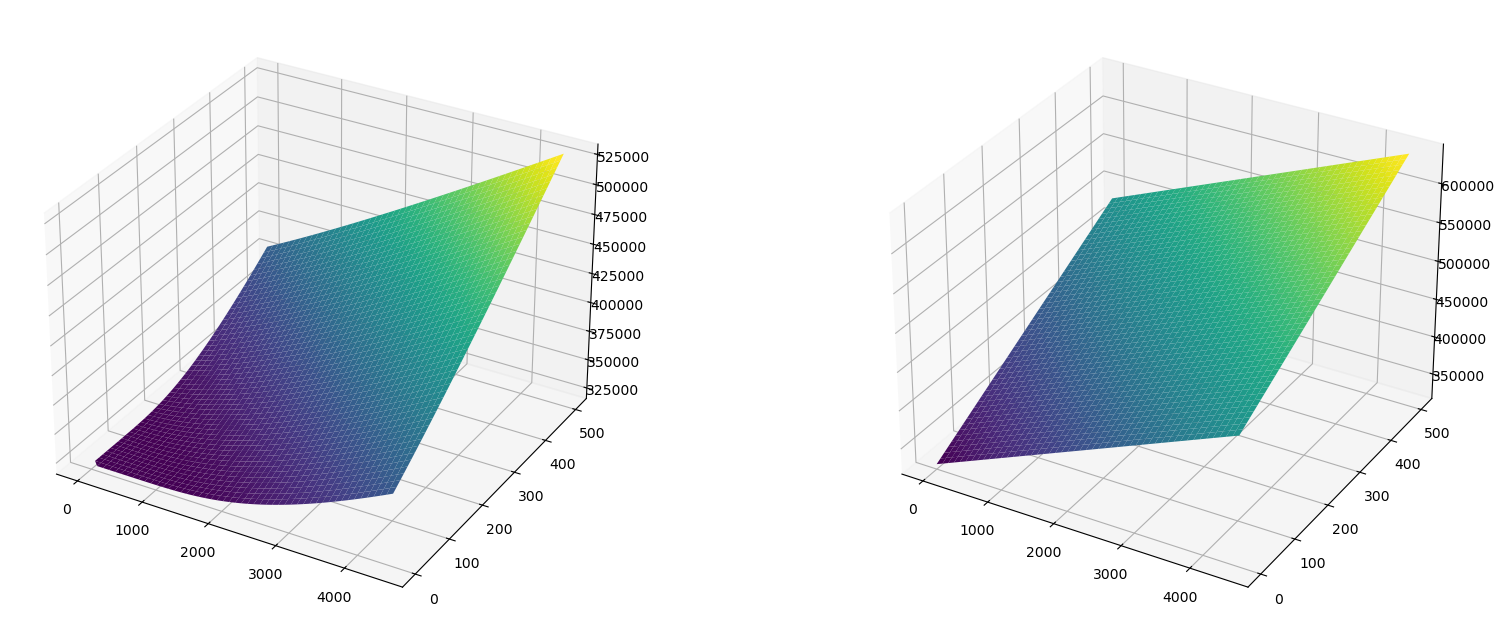

PyObject <mpl_toolkits.mplot3d.art3d.Poly3DCollection object at 0x0000019FB6C94220>

In [ ]:
fig, axs = plt.subplots(1, 2,figsize=(40,8))
pygui(false)
fc_size=1000
ST=range(0,500,50)
RT=range(0,4500,50)

axs[2].remove()
axs[1].remove()

axs[1] = fig.add_subplot(111, projection="3d")
axs[2] = fig.add_subplot(121, projection="3d")
fc= mg.dispatchables.fuel_cell[1]

RTs,STs=meshgrid(RT,ST)
Zpen = (fc.investment_price ./ fc.lifetime_hours) .* fc_size.*RTs  .+ (fc.investment_price ./ fc.lifetime_on_off) .* fc_size.*STs .+ CRF(0.2,mg.project.lifetime) .*fc.investment_price.*fc_size
#cs=axs[1].contour(RTs, STs, Zpen, levels=20, cmap="viridis")
#axs[1].clabel(cs, fontsize=10)
axs[1].plot_surface(RTs, STs, Zpen,cmap="viridis")
"""
axs[2].scatter(sub1.shed_energy[1:4],sub1.cost[1:4],c="orange",label=sub1.rule[1]);
axs[2].scatter(sub1.shed_energy[5:8],sub1.cost[5:8],c="blue",label=sub1.rule[5]);

for i=1:8
    axs[2].annotate(sub1.year_id[i], (sub1.shed_energy[i], sub1.cost[i]), textcoords="offset points", xytext=(5, 5), ha="center")
end
"""
#Tfc = min.((1 .- Eol) ./( RTs.*deg_ratio_rt .+ STs.*deg_ratio_st),fc.lifetime_calendar)
Tfc = (1 .- Eol) ./( RTs.*deg_ratio_rt .+ STs.*deg_ratio_st)
Znorm = fc.investment_price.*fc_size .* CRF.(0.2,Tfc)


axs[2].plot_surface(RTs, STs, Znorm,cmap="viridis")
#axs[2].clabel(cs2, fontsize=10)


In [ ]:
fc.investment_price*fc_size*CRF(0.115)

LoadError: MethodError: no method matching CRF(::Float64)
The function `CRF` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  CRF(::Any, [91m::Any[39m)
[0m[90m   @[39m [33mMain[39m [90m[4mIn[14]:1[24m[39m


In [ ]:
mg.project.discount_rate

0.05

In [ ]:
fig, axs = plt.subplots(1, 2,figsize=(20,8))

fc_size=10
ST=range(0,500,50)
RT=range(0,4500,50)

fc= mg.dispatchables.fuel_cell[1]

RTs,STs=meshgrid(RT,ST)

Tfc = (1 .- Eol) ./( RTs.*deg_ratio_rt .+ STs.*deg_ratio_st)
Znorm = fc.investment_price.*fc_size .* CRF.(0.1,Tfc)
axs[2].plot_surface(RTs, STs, Znorm, levels=20, cmap="viridis")

LoadError: KeyError: key :plot_surface not found

In [ ]:
fig = figure()
ax = fig.add_subplot(111)

fc_size=range(0,1500,500)
u=range(0,0.02,500)
Sizes,U=meshgrid(fc_size,u)

fc= mg.dispatchables.fuel_cell[1]


Tfc = min.((1 .- Eol) ./u,15)
Znorm = fc.investment_price.*fc_size .* CRF.(0.3,Tfc)
ax.plot(u, Znorm)
Zpen = (fc.investment_price ./ fc.lifetime_hours) .* fc_size.*(u./deg_ratio_rt).+ CRF(0.3,mg.project.lifetime) .*fc.investment_price.*fc_size
ax.plot(u, Zpen)

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x0000019FA6248730>

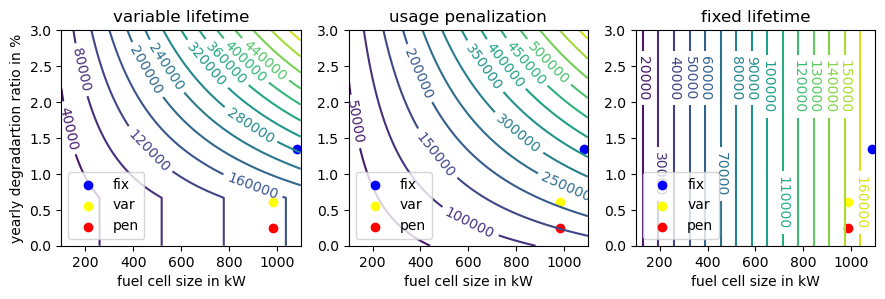

In [ ]:
fig, axs = plt.subplots(1, 3,figsize=(15*0.7,4*0.7))
pygui(false)
fc_size=range(100,1100,100)
z_tan = [0.20, 0.28, 0.37, 0.50, 0.68, 1.0, 1.7, 4.0] 
u=range(0.00,0.03,100)

Sizes,U=meshgrid(fc_size,u)
Uv=Sizes.* U./0.1

fc= mg.dispatchables.fuel_cell[1]
Tfc = min.((1 .- Eol) ./U,15)
#Tfc = (1 .- Eol) ./U
Zvar = fc.investment_price.*Sizes .* CRF.(0.05,Tfc)
Znorm = fc.investment_price.*cons_.(Sizes,Uv,fill(0.05,100),fill(15,100),fill(z_tan,100))
Zfix = fc.investment_price.*Sizes .* CRF.(0.05,15)
ufix= 2038*deg_ratio_rt + 458*deg_ratio_st 
sfix=1085
axs[1].scatter(sfix,100*ufix,c="blue",label="fix");
axs[2].scatter(sfix,100*ufix,c="blue",label="fix");
axs[3].scatter(sfix,100*ufix,c="blue",label="fix");

uvar= 1007*deg_ratio_rt + 199*deg_ratio_st 
svar=985
axs[1].scatter(svar,100*uvar,c="yellow",label="var");
axs[2].scatter(svar,100*uvar,c="yellow",label="var");
axs[3].scatter(svar,100*uvar,c="yellow",label="var");

upen= 688*deg_ratio_rt + 52*deg_ratio_st 
spen=985
axs[1].scatter(spen,100*upen,c="red",label="pen");
axs[2].scatter(spen,100*upen,c="red",label="pen");
axs[3].scatter(spen,100*upen,c="red",label="pen");


cs=axs[1].contour(Sizes, 100*U, Znorm, levels=15, cmap="viridis")

axs[1].clabel(cs, fontsize=10)

Zpen = (fc.investment_price ./ fc.lifetime_hours) .* Sizes.*(U/deg_ratio_rt) .+  CRF(0.05,mg.project.lifetime) .*fc.investment_price.*Sizes

cs2=axs[2].contour(Sizes,100* U, Zpen, levels=15, cmap="viridis")
axs[2].clabel(cs2, fontsize=10,inline=1)

cs3=axs[3].contour(Sizes,100* U, Zfix, levels=15, cmap="viridis")
axs[3].clabel(cs3, fontsize=10,inline=1)


axs[1].set(ylabel="yearly degradartion ratio in %")
axs[1].set(xlabel="fuel cell size in kW")
axs[2].set(xlabel="fuel cell size in kW")
axs[2].set(title="usage penalization")
axs[1].set(title="variable lifetime")
axs[3].set(title="fixed lifetime")
axs[3].set(xlabel="fuel cell size in kW")

axs[1].legend(loc="lower left")
axs[2].legend(loc="lower left")

axs[3].legend(loc="lower left")

plt.savefig("figures/value_map.png",dpi=1400,bbox_inches="tight")

In [ ]:
fill(z_tan,10)

10-element Vector{Vector{Float64}}:
 [0.2, 0.28, 0.37, 0.5, 0.68, 1.0, 1.7, 4.0]
 [0.2, 0.28, 0.37, 0.5, 0.68, 1.0, 1.7, 4.0]
 [0.2, 0.28, 0.37, 0.5, 0.68, 1.0, 1.7, 4.0]
 [0.2, 0.28, 0.37, 0.5, 0.68, 1.0, 1.7, 4.0]
 [0.2, 0.28, 0.37, 0.5, 0.68, 1.0, 1.7, 4.0]
 [0.2, 0.28, 0.37, 0.5, 0.68, 1.0, 1.7, 4.0]
 [0.2, 0.28, 0.37, 0.5, 0.68, 1.0, 1.7, 4.0]
 [0.2, 0.28, 0.37, 0.5, 0.68, 1.0, 1.7, 4.0]
 [0.2, 0.28, 0.37, 0.5, 0.68, 1.0, 1.7, 4.0]
 [0.2, 0.28, 0.37, 0.5, 0.68, 1.0, 1.7, 4.0]

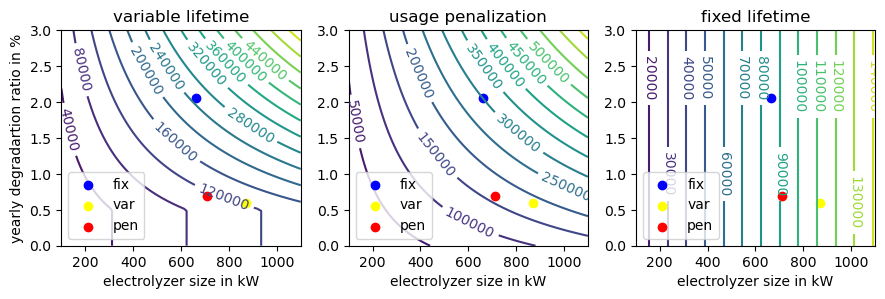

In [ ]:
fig, axs = plt.subplots(1, 3,figsize=(15*0.7,4*0.7))
pygui(false)
el_size=range(100,1100,100)
u=range(0.00,0.03,100)
Sizes,U=meshgrid(el_size,u)
el= mg.electrolyzer[1]
Tel = min.((1 .- Eol) ./U,20)
#Tfc = (1 .- Eol) ./U
Znorm = el.investment_price.*Sizes .* CRF.(0.05,Tel)
Zfix =el.investment_price.*Sizes .* CRF.(0.05,20)
ufix= 5138*deg_ratio_rt + 478*deg_ratio_st 
sfix=663
axs[1].scatter(sfix,100*ufix,c="blue",label="fix");
axs[2].scatter(sfix,100*ufix,c="blue",label="fix");
axs[3].scatter(sfix,100*ufix,c="blue",label="fix");

uvar= 2296*deg_ratio_rt + 54*deg_ratio_st 
svar=871
axs[1].scatter(svar,100*uvar,c="yellow",label="var");
axs[2].scatter(svar,100*uvar,c="yellow",label="var");
axs[3].scatter(svar,100*uvar,c="yellow",label="var");

upen= 2708*deg_ratio_rt + 53*deg_ratio_st 
spen=710
axs[1].scatter(spen,100*upen,c="red",label="pen");
axs[2].scatter(spen,100*upen,c="red",label="pen");
axs[3].scatter(spen,100*upen,c="red",label="pen");


cs=axs[1].contour(Sizes, 100*U, Znorm, levels=15, cmap="viridis")

axs[1].clabel(cs, fontsize=10)

Zpen = (el.investment_price ./ el.lifetime_hours) .* Sizes.*(U/deg_ratio_rt) .+  CRF(0.05,mg.project.lifetime) .*el.investment_price.*Sizes

cs2=axs[2].contour(Sizes,100* U, Zpen, levels=15, cmap="viridis")
axs[2].clabel(cs2, fontsize=10,inline=1)

cs3=axs[3].contour(Sizes,100* U, Zfix, levels=15, cmap="viridis")
axs[3].clabel(cs3, fontsize=10,inline=1)


axs[1].set(ylabel="yearly degradartion ratio in %")
axs[1].set(xlabel="electrolyzer size in kW")
axs[2].set(xlabel="electrolyzer size in kW")
axs[2].set(title="usage penalization")
axs[1].set(title="variable lifetime")
axs[3].set(title="fixed lifetime")
axs[3].set(xlabel="electrolyzer size in kW")

axs[1].legend(loc="lower left")
axs[2].legend(loc="lower left")

axs[3].legend(loc="lower left")

plt.savefig("figures/value_map_el.png",dpi=1400,bbox_inches="tight")

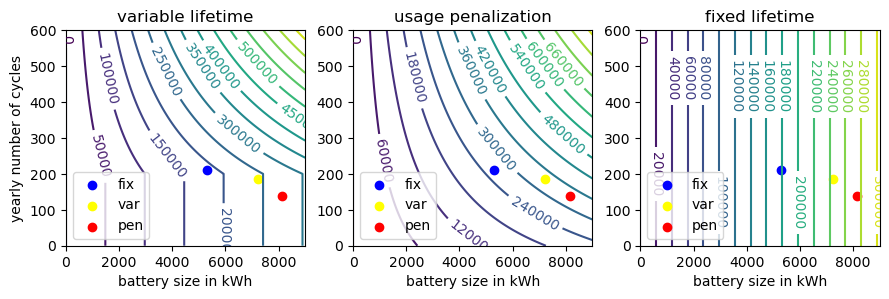

In [ ]:
fig, axs = plt.subplots(1, 3,figsize=(15*0.7,4*0.7))
pygui(false)
bt_size=range(0,9000,100)
u=range(0,600,100)
Sizes,U=meshgrid(bt_size,u)
bt= mg.storage
Tbt = min.(bt.lifetime_cycles ./ U,15)
#Tfc = (1 .- Eol) ./U
Znorm = bt.investment_price.*Sizes .* CRF.(0.05,Tbt)
Zfix =bt.investment_price.*Sizes .* CRF.(0.05,15)

ufix= 210
sfix=5292
axs[1].scatter(sfix,ufix,c="blue",label="fix");
axs[2].scatter(sfix,ufix,c="blue",label="fix");
axs[3].scatter(sfix,ufix,c="blue",label="fix");

uvar=187
svar= 7229
axs[1].scatter(svar,uvar,c="yellow",label="var");
axs[2].scatter(svar,uvar,c="yellow",label="var");
axs[3].scatter(svar,uvar,c="yellow",label="var");

upen= 137
spen=8144
axs[1].scatter(spen,upen,c="red",label="pen");
axs[2].scatter(spen,upen,c="red",label="pen");
axs[3].scatter(spen,upen,c="red",label="pen");


cs=axs[1].contour(Sizes, U, Znorm, levels=15, cmap="viridis")

axs[1].clabel(cs, fontsize=10)

Zpen =( U / bt.lifetime_cycles .+  CRF(0.05,mg.project.lifetime) ).*bt.investment_price.*Sizes

cs2=axs[2].contour(Sizes, U, Zpen, levels=15, cmap="viridis")
axs[2].clabel(cs2, fontsize=10,inline=1)

cs3=axs[3].contour(Sizes, U, Zfix, levels=15, cmap="viridis")
axs[3].clabel(cs3, fontsize=10,inline=1)


axs[1].set(ylabel="yearly number of cycles")
axs[1].set(xlabel="battery size in kWh")
axs[2].set(xlabel="battery size in kWh")
axs[2].set(title="usage penalization")
axs[1].set(title="variable lifetime")
axs[3].set(title="fixed lifetime")
axs[3].set(xlabel="battery size in kWh")

axs[1].legend(loc="lower left")
axs[2].legend(loc="lower left")

axs[3].legend(loc="lower left")

plt.savefig("figures/value_map_el.png",dpi=1400,bbox_inches="tight")

In [ ]:
function k_euro_formatter(val, pos=0.0)
    return string(round(val / 1000; digits=1), "k€")
end

k_euro_formatter (generic function with 2 methods)

In [ ]:
fig, axs = plt.subplots(4, 3,figsize=(16*0.6,15*0.6*4/3),constrained_layout = true)

fc_size=range(0,1100,100)
u=range(0.00,0.03,100)
Sizes,U=meshgrid(fc_size,u)
fc= mg.dispatchables.fuel_cell[1]
Uv=Sizes.* U./0.1
Tfc = min.((1 .- Eol) ./U,15)
#Tfc = (1 .- Eol) ./U
Zreal = fc.investment_price.*Sizes .* CRF.(0.05,Tfc)
Znorm = fc.investment_price.*cons_.(Sizes,Uv,fill(0.05,100),fill(15,100),fill(z_tan,100))
Zfix = fc.investment_price.*Sizes .* CRF.(0.05,15)
ufix= 2038*deg_ratio_rt + 458*deg_ratio_st 
sfix=1085
axs[1,1].scatter(sfix,100*ufix,c="blue",label="fix");
axs[1,2].scatter(sfix,100*ufix,c="blue",label="fix");
axs[1,3].scatter(sfix,100*ufix,c="blue",label="fix");

axs[1,1].plot(fc_size,10/15 .*ones(100),"k--",label="calendar lifetime");



uvar= 1007*deg_ratio_rt + 199*deg_ratio_st 
svar=985
axs[1,1].scatter(svar,100*uvar,c="yellow",label="var");
axs[1,2].scatter(svar,100*uvar,c="yellow",label="var");
axs[1,3].scatter(svar,100*uvar,c="yellow",label="var");

upen= 688*deg_ratio_rt + 52*deg_ratio_st 
spen=985
axs[1,1].scatter(spen,100*upen,c="red",label="pen");
axs[1,2].scatter(spen,100*upen,c="red",label="pen");
axs[1,3].scatter(spen,100*upen,c="red",label="pen");


cs=axs[1,1].contour(Sizes, 100*U, Znorm, levels=15, cmap="viridis")

axs[1,1].clabel(cs, fontsize=12,fmt=k_euro_formatter)

Zpen = (fc.investment_price ./ fc.lifetime_hours) .* Sizes.*(U/deg_ratio_rt) .+  CRF(0.05,mg.project.lifetime) .*fc.investment_price.*Sizes

cs2=axs[1,2].contour(Sizes,100* U, Zpen, levels=15, cmap="viridis")
axs[1,2].clabel(cs2, fontsize=12,inline=1,fmt=k_euro_formatter)

cs3=axs[1,3].contour(Sizes,100* U, Zfix, levels=15, cmap="viridis")
axs[1,3].clabel(cs3, fontsize=12,inline=1,fmt=k_euro_formatter)




el_size=range(100,1100,100)
u=range(0.00,0.03,100)
Sizes,U=meshgrid(el_size,u)
el= mg.electrolyzer[1]
Tel = min.((1 .- Eol) ./U,20)
#Tfc = (1 .- Eol) ./U
#Znorm = el.investment_price.*Sizes .* CRF.(0.05,Tel)
Znorm =el.investment_price.*cons_.(Sizes,Uv,fill(0.05,100),fill(20,100),fill(z_tan,100))
Zfix =el.investment_price.*Sizes .* CRF.(0.05,20)
ufix= 5138*deg_ratio_rt + 478*deg_ratio_st 
sfix=663
axs[2,1].scatter(sfix,100*ufix,c="blue",label="fix");
axs[2,2].scatter(sfix,100*ufix,c="blue",label="fix");
axs[2,3].scatter(sfix,100*ufix,c="blue",label="fix");

uvar= 2296*deg_ratio_rt + 54*deg_ratio_st 
svar=871
axs[2,1].scatter(svar,100*uvar,c="yellow",label="var");
axs[2,2].scatter(svar,100*uvar,c="yellow",label="var");
axs[2,3].scatter(svar,100*uvar,c="yellow",label="var");

upen= 2708*deg_ratio_rt + 53*deg_ratio_st 
spen=710
axs[2,1].scatter(spen,100*upen,c="red",label="pen");
axs[2,2].scatter(spen,100*upen,c="red",label="pen");
axs[2,3].scatter(spen,100*upen,c="red",label="pen");


cs=axs[2,1].contour(Sizes, 100*U, Znorm, levels=15, cmap="viridis")

axs[2,1].clabel(cs, fontsize=12,fmt=k_euro_formatter)

Zpen = (el.investment_price ./ el.lifetime_hours) .* Sizes.*(U/deg_ratio_rt) .+  CRF(0.05,mg.project.lifetime) .*el.investment_price.*Sizes

cs2=axs[2,2].contour(Sizes,100* U, Zpen, levels=15, cmap="viridis")
axs[2,2].clabel(cs2, fontsize=10,inline=1,fmt=k_euro_formatter)

cs3=axs[2,3].contour(Sizes,100* U, Zfix, levels=15, cmap="viridis")
axs[2,3].clabel(cs3, fontsize=12,inline=1,fmt=k_euro_formatter)

#fig.tight_layout(xpad=2.5)

axs[2,1].plot(el_size,10/20 .*ones(100),"k--",label="calendar lifetime");


bt_size=range(0,9000,100)
u=range(0,600,100)
Sizes,U=meshgrid(bt_size,u)
Uv=U.*Sizes./3000
bt= mg.storage
Tbt = min.(bt.lifetime_cycles ./ U,15)
#Tfc = (1 .- Eol) ./U
#Znorm = bt.investment_price.*Sizes .* CRF.(0.05,Tbt)
Znorm =bt.investment_price.*cons_.(Sizes,Uv,fill(0.05,100),fill(15,100),fill(z_tan,100))
Zfix =bt.investment_price.*Sizes .* CRF.(0.05,15)

ufix= 210
sfix=5292
fix=axs[3,1].scatter(sfix,ufix,c="blue",label="fix");
axs[3,2].scatter(sfix,ufix,c="blue",label="fix");
axs[3,3].scatter(sfix,ufix,c="blue",label="fix");

uvar=187
svar= 7229
var=axs[3,1].scatter(svar,uvar,c="yellow",label="var");
axs[3,2].scatter(svar,uvar,c="yellow",label="var");
axs[3,3].scatter(svar,uvar,c="yellow",label="var");

upen= 137
spen=8144
pen=axs[3,1].scatter(spen,upen,c="red",label="pen");
axs[3,2].scatter(spen,upen,c="red",label="pen");
axs[3,3].scatter(spen,upen,c="red",label="pen");


cs=axs[3,1].contour(Sizes, U, Znorm, levels=15, cmap="viridis")

axs[3,1].clabel(cs, fontsize=12,fmt=k_euro_formatter)

Zpen =( U / bt.lifetime_cycles .+  CRF(0.05,mg.project.lifetime) ).*bt.investment_price.*Sizes

cs2=axs[3,2].contour(Sizes, U, Zpen, levels=15, cmap="viridis")
axs[3,2].clabel(cs2, fontsize=12,inline=1,fmt=k_euro_formatter)

cs3=axs[3,3].contour(Sizes, U, Zfix, levels=15, cmap="viridis")
axs[3,3].clabel(cs3, fontsize=12,inline=1,fmt=k_euro_formatter)
cal=axs[3,1].plot(bt_size,3000/15 .*ones(100),"k--",label="calendar lifetime");

axs[3,1].set_ylabel("usage penalization \n yearly number of cycles",fontsize=12)
axs[2,1].set(ylabel="variable lifetime \n yearly degradartion ratio in %")
axs[1,1].set(ylabel="real cost \n yearly degradartion ratio in %")
axs[4,1].set(ylabel="fix penalization \n yearly degradartion ratio in %")

axs[1,1].set(xlabel="fuel cell size in kW")
axs[1,2].set(xlabel="fuel cell size in kW")
axs[1,3].set(xlabel="fuel cell size in kW")
axs[2,1].set(xlabel="electrolyzer size in kW")
axs[2,2].set(xlabel="electrolyzer size in kW")
axs[2,3].set(xlabel="electrolyzer size in kW")
axs[3,1].set(xlabel="battery size in kWh")
axs[3,2].set(xlabel="battery size in kWh")
axs[3,3].set(xlabel="battery size in kWh")
#axs[2].set(xlabel="fuel cell size in kW")
"""
axs[1,2].set(title="usage penalization")
axs[1,1].set_title("variable lifetime")
axs[1,3].set(title="fixed lifetime")
"""
#axs[1,1].legend(cal,["calendar lifetime"],loc="upper right",ncols=1)
"""
axs[1,2].legend(loc="upper left")
axs[1,3].legend(loc="upper left")

axs[2,1].legend(loc="upper left")
axs[2,2].legend(loc="upper left")
axs[2,3].legend(loc="upper left")

axs[3,1].legend(loc="upper left")
axs[3,2].legend(loc="upper left")
axs[3,3].legend(loc="upper left")
"""

fig.legend([var,fix,pen],["var","fix","pen"],bbox_to_anchor=(0.41, 1.01),ncols=3,loc="center")
fig.legend(cal,["calendar lifetime"],bbox_to_anchor=(0.627, 1.01),ncols=3,loc="center")
plt.savefig("figures/big_fig.jpeg",dpi=1400,bbox_inches="tight")

LoadError: UndefVarError: `plt` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

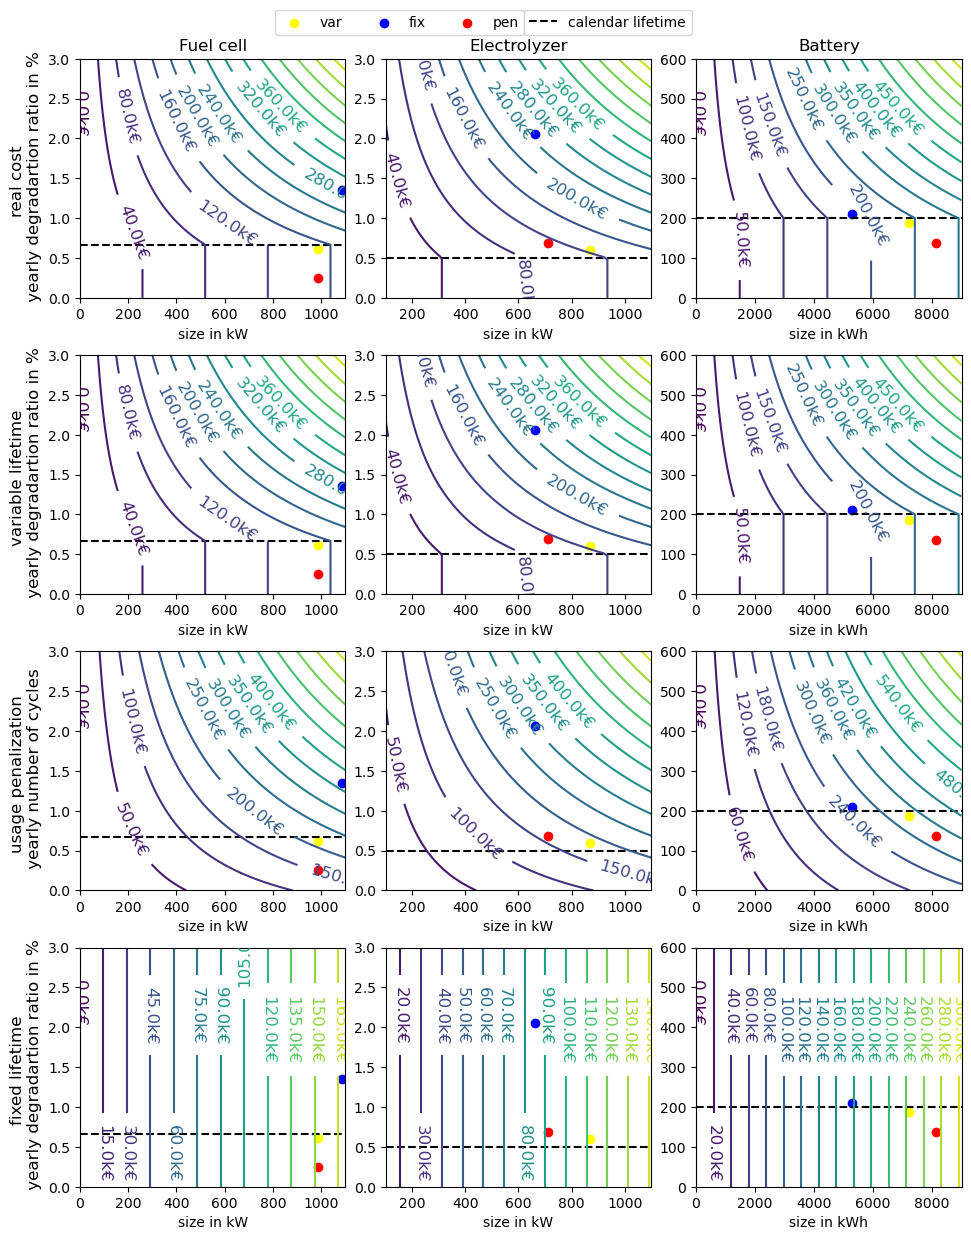

In [ ]:
fig, axs = plt.subplots(4, 3,figsize=(16*0.6,15*0.6*4/3),constrained_layout = true)

fc_size=range(0,1100,100)
u=range(0.00,0.03,100)
Sizes,U=meshgrid(fc_size,u)
fc= mg.dispatchables.fuel_cell[1]
Uv=Sizes.* U./0.1
Tfc = min.((1 .- Eol) ./U,15)
#Tfc = (1 .- Eol) ./U
Zreal = fc.investment_price.*Sizes .* CRF.(0.05,Tfc)
Znorm = fc.investment_price.*cons_.(Sizes,Uv,fill(0.05,100),fill(15,100),fill(z_tan,100))
Zfix = fc.investment_price.*Sizes .* CRF.(0.05,15)
Zpen = (fc.investment_price ./ fc.lifetime_hours) .* Sizes.*(U/deg_ratio_rt) .+  CRF(0.05,mg.project.lifetime) .*fc.investment_price.*Sizes

ufix= 2038*deg_ratio_rt + 458*deg_ratio_st 
sfix=1085





uvar= 1007*deg_ratio_rt + 199*deg_ratio_st 
svar=985




upen= 688*deg_ratio_rt + 52*deg_ratio_st 
spen=985


for i=1:4
    axs[i,1].scatter(sfix,100*ufix,c="blue",label="fix");
    axs[i,1].plot(fc_size,10/15 .*ones(100),"k--",label="calendar lifetime");
    axs[i,1].scatter(svar,100*uvar,c="yellow",label="var");
    axs[i,1].scatter(spen,100*upen,c="red",label="pen");
end

csr=axs[1,1].contour(Sizes, 100*U, Zreal, levels=15, cmap="viridis")
cs=axs[2,1].contour(Sizes, 100*U, Znorm, levels=15, cmap="viridis")
cs2=axs[3,1].contour(Sizes,100* U, Zpen, levels=15, cmap="viridis")
cs3=axs[4,1].contour(Sizes,100* U, Zfix, levels=15, cmap="viridis")

axs[1,1].clabel(csr, fontsize=12,fmt=k_euro_formatter)
axs[2,1].clabel(cs, fontsize=12,fmt=k_euro_formatter)
axs[3,1].clabel(cs2, fontsize=12,inline=1,fmt=k_euro_formatter)
axs[4,1].clabel(cs3, fontsize=12,inline=1,fmt=k_euro_formatter)




el_size=range(100,1100,100)
u=range(0.00,0.03,100)
Sizes,U=meshgrid(el_size,u)
el= mg.electrolyzer[1]
Tel = min.((1 .- Eol) ./U,20)
Uv=Sizes.* U./0.1
Zreal = el.investment_price.*Sizes .* CRF.(0.05,Tel)
Znorm =el.investment_price.*cons_.(Sizes,Uv,fill(0.05,100),fill(20,100),fill(z_tan,100))
Zfix =el.investment_price.*Sizes .* CRF.(0.05,20)
Zpen = (el.investment_price ./ el.lifetime_hours) .* Sizes.*(U/deg_ratio_rt) .+  CRF(0.05,mg.project.lifetime) .*el.investment_price.*Sizes
ufix= 5138*deg_ratio_rt + 478*deg_ratio_st 
sfix=663
uvar= 2296*deg_ratio_rt + 54*deg_ratio_st 
svar=871
upen= 2708*deg_ratio_rt + 53*deg_ratio_st 
spen=710

for i=1:4
    axs[i,2].scatter(sfix,100*ufix,c="blue",label="fix");
    axs[i,2].plot(el_size,10/20 .*ones(100),"k--",label="calendar lifetime");
    axs[i,2].scatter(svar,100*uvar,c="yellow",label="var");
    axs[i,2].scatter(spen,100*upen,c="red",label="pen");
end

csr=axs[1,2].contour(Sizes, 100*U, Zreal, levels=15, cmap="viridis")
cs=axs[2,2].contour(Sizes, 100*U, Znorm, levels=15, cmap="viridis")
cs2=axs[3,2].contour(Sizes,100* U, Zpen, levels=15, cmap="viridis")
cs3=axs[4,2].contour(Sizes,100* U, Zfix, levels=15, cmap="viridis")

axs[1,2].clabel(csr, fontsize=12,fmt=k_euro_formatter)
axs[2,2].clabel(cs, fontsize=12,fmt=k_euro_formatter)
axs[3,2].clabel(cs2, fontsize=12,inline=1,fmt=k_euro_formatter)
axs[4,2].clabel(cs3, fontsize=12,inline=1,fmt=k_euro_formatter)


bt_size=range(0,9000,100)
u=range(0,600,100)
Sizes,U=meshgrid(bt_size,u)
Uv=U.*Sizes./3000
bt= mg.storage
Tbt = min.(bt.lifetime_cycles ./ U,15)
#Tfc = (1 .- Eol) ./U
Zreal = bt.investment_price.*Sizes .* CRF.(0.05,Tbt)
Znorm =bt.investment_price.*cons_.(Sizes,Uv,fill(0.05,100),fill(15,100),fill(z_tan,100))
Zfix =bt.investment_price.*Sizes .* CRF.(0.05,15)
Zpen =( U / bt.lifetime_cycles .+  CRF(0.05,mg.project.lifetime) ).*bt.investment_price.*Sizes

ufix= 210
sfix=5292

uvar=187
svar= 7229
upen= 137
spen=8144

for i=1:4
   fix= axs[i,3].scatter(sfix,ufix,c="blue",label="fix");
    axs[i,3].plot(bt_size,3000/15 .*ones(100),"k--",label="calendar lifetime");
   var= axs[i,3].scatter(svar,uvar,c="yellow",label="var");
   pen= axs[i,3].scatter(spen,upen,c="red",label="pen");
end 

csr=axs[1,3].contour(Sizes, U, Zreal, levels=15, cmap="viridis")
cs=axs[2,3].contour(Sizes, U, Znorm, levels=15, cmap="viridis")
cs2=axs[3,3].contour(Sizes, U, Zpen, levels=15, cmap="viridis")
cs3=axs[4,3].contour(Sizes, U, Zfix, levels=15, cmap="viridis")

axs[1,3].clabel(csr, fontsize=12,fmt=k_euro_formatter)
axs[2,3].clabel(cs, fontsize=12,fmt=k_euro_formatter)
axs[3,3].clabel(cs2, fontsize=12,inline=1,fmt=k_euro_formatter)
axs[4,3].clabel(cs3, fontsize=12,inline=1,fmt=k_euro_formatter)




axs[3,1].set_ylabel("usage penalization \n yearly number of cycles",fontsize=12)
axs[2,1].set_ylabel("variable lifetime \n yearly degradartion ratio in %",fontsize=12)
axs[1,1].set_ylabel("real cost \n yearly degradartion ratio in %",fontsize=12)
axs[4,1].set_ylabel("fixed lifetime \n yearly degradartion ratio in %",fontsize=12)
for i=1:4
    axs[i,1].set(xlabel="size in kW")
    axs[i,2].set(xlabel="size in kW")
    axs[i,3].set(xlabel="size in kWh")
    
end

axs[1,].set(title="Fuel cell")
axs[1,2].set_title("Electrolyzer")
axs[1,3].set(title="Battery")


#axs[1,1].legend(cal,["calendar lifetime"],loc="upper right",ncols=1)
"""
axs[1,2].legend(loc="upper left")
axs[1,3].legend(loc="upper left")

axs[2,1].legend(loc="upper left")
axs[2,2].legend(loc="upper left")
axs[2,3].legend(loc="upper left")

axs[3,1].legend(loc="upper left")
axs[3,2].legend(loc="upper left")
axs[3,3].legend(loc="upper left")
"""

fig.legend([var,fix,pen],["var","fix","pen"],bbox_to_anchor=(0.41, 1.01),ncols=3,loc="center")
fig.legend(cal,["calendar lifetime"],bbox_to_anchor=(0.627, 1.01),ncols=3,loc="center")
plt.savefig("figures/big_fig.jpeg",dpi=1400,bbox_inches="tight")

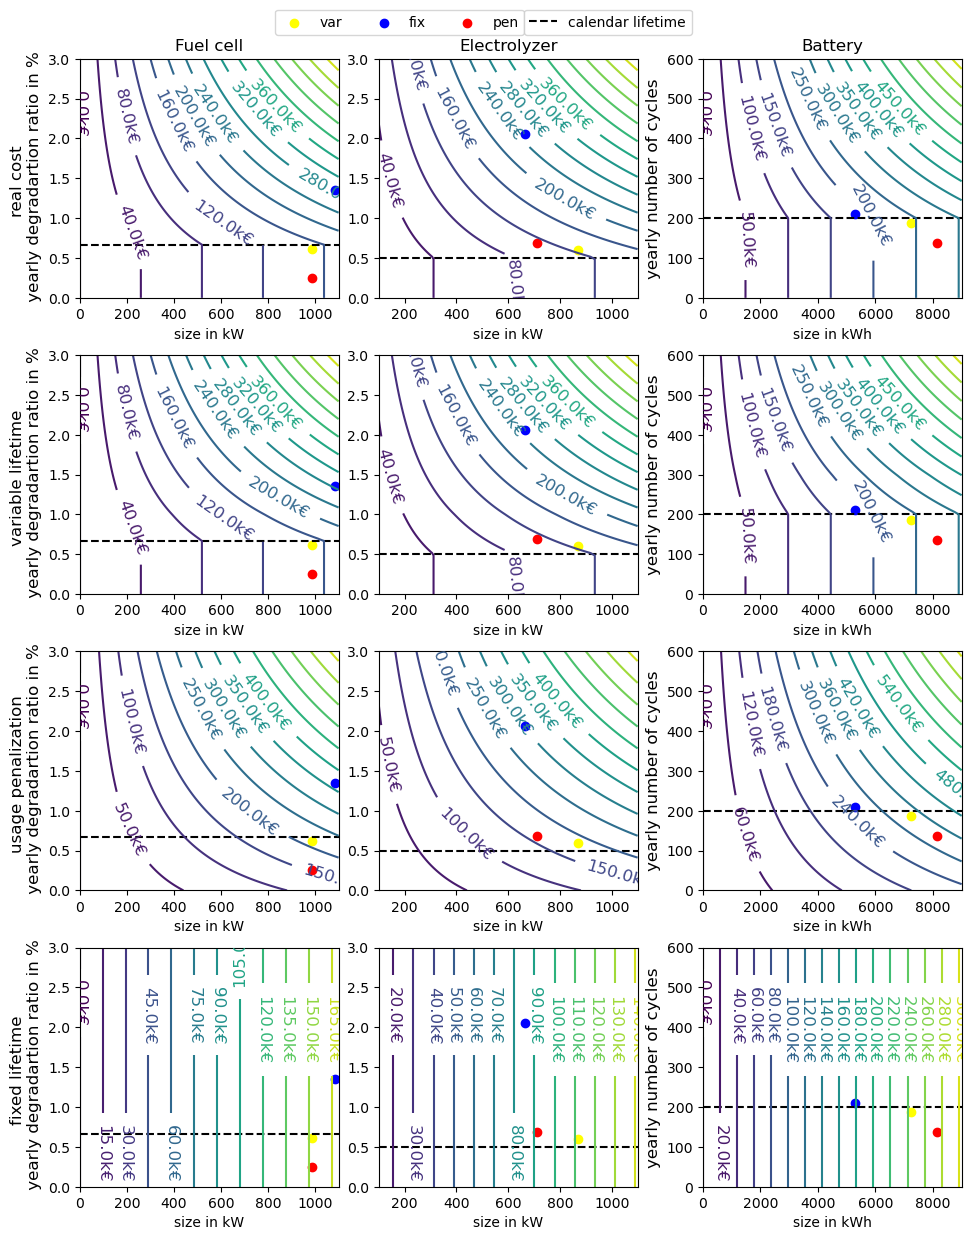

In [ ]:
fig, axs = plt.subplots(4, 3,figsize=(16*0.6,15*0.6*4/3),constrained_layout = true)

fc_size=range(0,1100,100)
u=range(0.00,0.03,100)
Sizes,U=meshgrid(fc_size,u)
fc= mg.dispatchables.fuel_cell[1]
Uv=Sizes.* U./0.1
Tfc = min.((1 .- Eol) ./U,15)
#Tfc = (1 .- Eol) ./U
Zreal = fc.investment_price.*Sizes .* CRF.(0.05,Tfc)
Znorm = fc.investment_price.*cons_.(Sizes,Uv,fill(0.05,100),fill(15,100))
Zfix = fc.investment_price.*Sizes .* CRF.(0.05,15)
Zpen = (fc.investment_price ./ fc.lifetime_hours) .* Sizes.*(U/deg_ratio_rt) .+  CRF(0.05,mg.project.lifetime) .*fc.investment_price.*Sizes

ufix= 2038*deg_ratio_rt + 458*deg_ratio_st 
sfix=1085



uvar= 1007*deg_ratio_rt + 199*deg_ratio_st 
svar=985


upen= 688*deg_ratio_rt + 52*deg_ratio_st 
spen=985


for i=1:4
    axs[i,1].scatter(sfix,100*ufix,c="blue",label="fix");
    axs[i,1].plot(fc_size,10/15 .*ones(100),"k--",label="calendar lifetime");
    axs[i,1].scatter(svar,100*uvar,c="yellow",label="var");
    axs[i,1].scatter(spen,100*upen,c="red",label="pen");
end

csr=axs[1,1].contour(Sizes, 100*U, Zreal, levels=15, cmap="viridis")
cs=axs[2,1].contour(Sizes, 100*U, Znorm, levels=15, cmap="viridis")
cs2=axs[3,1].contour(Sizes,100* U, Zpen, levels=15, cmap="viridis")
cs3=axs[4,1].contour(Sizes,100* U, Zfix, levels=15, cmap="viridis")

axs[1,1].clabel(csr, fontsize=12,fmt=k_euro_formatter)
axs[2,1].clabel(cs, fontsize=12,fmt=k_euro_formatter)
axs[3,1].clabel(cs2, fontsize=12,inline=1,fmt=k_euro_formatter)
axs[4,1].clabel(cs3, fontsize=12,inline=1,fmt=k_euro_formatter)




el_size=range(100,1100,100)
u=range(0.00,0.03,100)
Sizes,U=meshgrid(el_size,u)
el= mg.electrolyzer[1]
Tel = min.((1 .- Eol) ./U,20)
Uv=Sizes.* U./0.1
Zreal = el.investment_price.*Sizes .* CRF.(0.05,Tel)
Znorm =el.investment_price.*cons_.(Sizes,Uv,fill(0.05,100),fill(20,100))
Zfix =el.investment_price.*Sizes .* CRF.(0.05,20)
Zpen = (el.investment_price ./ el.lifetime_hours) .* Sizes.*(U/deg_ratio_rt) .+  CRF(0.05,mg.project.lifetime) .*el.investment_price.*Sizes
ufix= 5138*deg_ratio_rt + 478*deg_ratio_st 
sfix=663
uvar= 2296*deg_ratio_rt + 54*deg_ratio_st 
svar=871
upen= 2708*deg_ratio_rt + 53*deg_ratio_st 
spen=710

for i=1:4
    axs[i,2].scatter(sfix,100*ufix,c="blue",label="fix");
    axs[i,2].plot(el_size,10/20 .*ones(100),"k--",label="calendar lifetime");
    axs[i,2].scatter(svar,100*uvar,c="yellow",label="var");
    axs[i,2].scatter(spen,100*upen,c="red",label="pen");
end

csr=axs[1,2].contour(Sizes, 100*U, Zreal, levels=15, cmap="viridis")
cs=axs[2,2].contour(Sizes, 100*U, Znorm, levels=15, cmap="viridis")
cs2=axs[3,2].contour(Sizes,100* U, Zpen, levels=15, cmap="viridis")
cs3=axs[4,2].contour(Sizes,100* U, Zfix, levels=15, cmap="viridis")

axs[1,2].clabel(csr, fontsize=12,fmt=k_euro_formatter)
axs[2,2].clabel(cs, fontsize=12,fmt=k_euro_formatter)
axs[3,2].clabel(cs2, fontsize=12,inline=1,fmt=k_euro_formatter)
axs[4,2].clabel(cs3, fontsize=12,inline=1,fmt=k_euro_formatter)


bt_size=range(0,9000,100)
u=range(0,600,100)
Sizes,U=meshgrid(bt_size,u)
Uv=U.*Sizes./3000
bt= mg.storage
Tbt = min.(bt.lifetime_cycles ./ U,15)
#Tfc = (1 .- Eol) ./U
Zreal = bt.investment_price.*Sizes .* CRF.(0.05,Tbt)
Znorm =bt.investment_price.*cons_.(Sizes,Uv,fill(0.05,100),fill(15,100))
Zfix =bt.investment_price.*Sizes .* CRF.(0.05,15)
Zpen =( U / bt.lifetime_cycles .+  CRF(0.05,mg.project.lifetime) ).*bt.investment_price.*Sizes

ufix= 210
sfix=5292

uvar=187
svar= 7229
upen= 137
spen=8144

for i=1:4
   fixs= axs[i,3].scatter(sfix,ufix,c="blue",label="fix");
    cal=axs[i,3].plot(bt_size,3000/15 .*ones(100),"k--",label="calendar lifetime");
   var= axs[i,3].scatter(svar,uvar,c="yellow",label="var");
   pen= axs[i,3].scatter(spen,upen,c="red",label="pen");
end 

csr=axs[1,3].contour(Sizes, U, Zreal, levels=15, cmap="viridis")
cs=axs[2,3].contour(Sizes, U, Znorm, levels=15, cmap="viridis")
cs2=axs[3,3].contour(Sizes, U, Zpen, levels=15, cmap="viridis")
cs3=axs[4,3].contour(Sizes, U, Zfix, levels=15, cmap="viridis")

axs[1,3].clabel(csr, fontsize=12,fmt=k_euro_formatter)
axs[2,3].clabel(cs, fontsize=12,fmt=k_euro_formatter)
axs[3,3].clabel(cs2, fontsize=12,inline=1,fmt=k_euro_formatter)
axs[4,3].clabel(cs3, fontsize=12,inline=1,fmt=k_euro_formatter)





axs[3,1].set_ylabel("usage penalization \n yearly degradartion ratio in %",fontsize=12)
axs[2,1].set_ylabel("variable lifetime \n yearly degradartion ratio in %",fontsize=12)
axs[1,1].set_ylabel("real cost \n yearly degradartion ratio in %",fontsize=12)
axs[4,1].set_ylabel("fixed lifetime \n yearly degradartion ratio in %",fontsize=12)

axs[3,3].set_ylabel("yearly number of cycles",fontsize=12)
axs[2,3].set_ylabel("yearly number of cycles",fontsize=12)
axs[1,3].set_ylabel("yearly number of cycles",fontsize=12)
axs[4,3].set_ylabel("yearly number of cycles",fontsize=12)

for i=1:4
    axs[i,1].set(xlabel="size in kW")
    axs[i,2].set(xlabel="size in kW")
    axs[i,3].set(xlabel="size in kWh")
    
end

axs[1,].set(title="Fuel cell")
axs[1,2].set_title("Electrolyzer")
axs[1,3].set(title="Battery")


#axs[1,1].legend(cal,["calendar lifetime"],loc="upper right",ncols=1)
"""
axs[1,2].legend(loc="upper left")
axs[1,3].legend(loc="upper left")

axs[2,1].legend(loc="upper left")
axs[2,2].legend(loc="upper left")
axs[2,3].legend(loc="upper left")

axs[3,1].legend(loc="upper left")
axs[3,2].legend(loc="upper left")
axs[3,3].legend(loc="upper left")
"""

fig.legend([var,fixs,pen],["var","fix","pen"],bbox_to_anchor=(0.41, 1.01),ncols=3,loc="center")
fig.legend(cal,["calendar lifetime"],bbox_to_anchor=(0.627, 1.01),ncols=1,loc="center")
plt.savefig("figures/big_fig.jpeg",dpi=600,bbox_inches="tight")

In [ ]:
cs2

PyObject <matplotlib.contour.QuadContourSet object at 0x000001193AA7B430>

In [ ]:
var=0

0

In [ ]:
fixs=0

0

In [ ]:
cal=0

0